In [19]:
# CLEAN CONSENSUS METABOLITE PANEL PIPELINE

import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# =========================
# SETTINGS
# =========================

BASE = "../.."
META_PATH = f"{BASE}/data/metadata/Metadata_061523.csv"
METAB_PATH = f"{BASE}/data/metabolomics/Metabolomics_maaslined_norun.csv"

RANDOM_STATE = 42
OUT_DIR = f"{BASE}/output/consensus_metabolite_panel_clean"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# LOAD + CLEAN DATA
# =========================

meta_raw = pd.read_csv(META_PATH)
metab_raw = pd.read_csv(METAB_PATH)

metab = (
    metab_raw
    .set_index("Unnamed: 0")
    .T
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

metab["participant_id"] = metab["sample_id"].str.replace(r"_tp\d+$", "", regex=True)
metab["timepoint"] = metab["sample_id"].str.extract(r"_tp(\d+)")

tp1 = metab[metab["timepoint"] == "1"].copy()

meta_raw["participant_id"] = meta_raw["samples_id"].astype(str)
meta_tp1 = meta_raw[meta_raw["timepoints"] == "tp1"].copy()

df = tp1.merge(meta_tp1, on="participant_id", how="inner")

y = df["study_ptorhc"].map({"MECFS": 1, "Control": 0})

metadata_cols = list(meta_raw.columns) + ["sample_id", "participant_id", "timepoint"]
feature_cols = [c for c in df.columns if c not in metadata_cols]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.loc[:, X.notna().all()]

print("Full X:", X.shape)
print("Class counts:", y.value_counts().to_dict())

# =========================
# FREEZE HELD-OUT TEST SET
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

# =========================
# CONSENSUS FEATURE SELECTION
# repeated CV LASSO on TRAIN ONLY
# =========================

C_GRID = [0.01, 0.03, 0.06, 0.1, 0.3]
N_REPEATS = 20
N_SPLITS = 5

counts = pd.Series(0, index=X_train.columns, dtype=int)

for repeat in range(N_REPEATS):
    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat
    )
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        
        for C in C_GRID:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("lasso", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=5000,
                    random_state=RANDOM_STATE
                ))
            ])
            
            model.fit(X_tr, y_tr)
            coefs = model.named_steps["lasso"].coef_[0]
            selected = X_train.columns[coefs != 0]
            counts[selected] += 1

total_runs = N_REPEATS * N_SPLITS * len(C_GRID)

consensus_df = pd.DataFrame({
    "metabolite": counts.index,
    "count": counts.values,
    "frequency": counts.values / total_runs
}).sort_values(["count", "metabolite"], ascending=[False, True]).reset_index(drop=True)

consensus_df["rank"] = consensus_df.index + 1

print("\n===== TOP 40 CONSENSUS METABOLITES =====")
display(consensus_df.head(40))

# =========================
# BUILD PANELS FROM CONSENSUS RANKING
# =========================

ordered_features = consensus_df["metabolite"].tolist()
panel_sizes = [3, 5, 8, 10, 15]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for k in panel_sizes:
    feats = ordered_features[:k]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])
    
    aucs = cross_val_score(
        model,
        X_train[feats],
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    
    results.append({
        "panel_size": k,
        "mean_train_cv_auc": aucs.mean(),
        "std_train_cv_auc": aucs.std(),
        "features": feats
    })

results_df = pd.DataFrame(results)

print("\n===== TRAIN-ONLY PANEL CV RESULTS =====")
display(results_df[["panel_size", "mean_train_cv_auc", "std_train_cv_auc"]])

# =========================
# SELECT BEST TRADEOFF PANEL
# =========================

tradeoff_df = results_df.copy()

# Sort by panel size
tradeoff_df = tradeoff_df.sort_values("panel_size").reset_index(drop=True)

# Calculate gains from adding more metabolites
tradeoff_df["auc_gain_from_previous"] = tradeoff_df["mean_train_cv_auc"].diff()
tradeoff_df["features_added"] = tradeoff_df["panel_size"].diff()
tradeoff_df["auc_gain_per_added_feature"] = (
    tradeoff_df["auc_gain_from_previous"] / tradeoff_df["features_added"]
)
    
# Define best AUC
best_auc = tradeoff_df["mean_train_cv_auc"].max()

# Rule:
# choose the smallest panel with CV AUC at least 95% of best AUC
# AND mean CV AUC >= 0.85 if possible
tradeoff_df["pct_of_best_auc"] = tradeoff_df["mean_train_cv_auc"] / best_auc

eligible = tradeoff_df[
    (tradeoff_df["pct_of_best_auc"] >= 0.95) &
    (tradeoff_df["mean_train_cv_auc"] >= 0.85)
].copy()

if len(eligible) == 0:
    chosen_tradeoff = tradeoff_df.sort_values(
        ["mean_train_cv_auc", "panel_size"],
        ascending=[False, True]
    ).iloc[0]
else:
    chosen_tradeoff = eligible.sort_values(
        ["panel_size", "mean_train_cv_auc"],
        ascending=[True, False]
    ).iloc[0]

TRADEOFF_PANEL_SIZE = int(chosen_tradeoff["panel_size"])
TRADEOFF_FEATURES = chosen_tradeoff["features"]

print("===== PANEL TRADEOFF TABLE =====")
display(
    tradeoff_df[
        [
            "panel_size",
            "mean_train_cv_auc",
            "std_train_cv_auc",
            "auc_gain_from_previous",
            "auc_gain_per_added_feature",
            "pct_of_best_auc"
        ]
    ]
)

print("\n===== SELECTED TRADEOFF PANEL =====")
print("Panel size:", TRADEOFF_PANEL_SIZE)
print("CV AUC:", chosen_tradeoff["mean_train_cv_auc"], "+/-", chosen_tradeoff["std_train_cv_auc"])
print("Percent of best AUC:", chosen_tradeoff["pct_of_best_auc"])

print("\nFeatures:")
for f in TRADEOFF_FEATURES:
    print("-", f)
    
tradeoff_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

tradeoff_model.fit(X_train[TRADEOFF_FEATURES], y_train)

test_probs = tradeoff_model.predict_proba(X_test[TRADEOFF_FEATURES])[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("\n===== 10-PANEL HELD-OUT TEST PERFORMANCE =====")
print("AUC:", roc_auc_score(y_test, test_probs))
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_preds))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_preds))

print("\nClassification report:")
print(classification_report(y_test, test_preds))

coef_10 = pd.Series(
    tradeoff_model.named_steps["logreg"].coef_[0],
    index=TRADEOFF_FEATURES
).sort_values(key=abs, ascending=False)

intercept_10 = tradeoff_model.named_steps["logreg"].intercept_[0]

print("\nIntercept:", intercept_10)
print("\nCoefficients:")
display(coef_10)

Full X: (214, 876)
Class counts: {1: 135, 0: 79}
Train: (171, 876) {1: 108, 0: 63}
Test: (43, 876) {1: 27, 0: 16}

===== TOP 40 CONSENSUS METABOLITES =====


,metabolite,count,frequency,rank
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),254,0.508,1
1,N-acetylglutamate,251,0.502,2
2,N4-acetylcytidine,233,0.466,3
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",232,0.464,4
4,1-methylurate,228,0.456,5
5,N-palmitoyl-sphingosine (d18:1/16:0),228,0.456,6
6,3-(4-hydroxyphenyl)lactate,214,0.428,7
7,N-acetylglucosamine/N-acetylgalactosamine,173,0.346,8
8,vanillylmandelate (VMA),156,0.312,9
9,4-vinylguaiacol sulfate,149,0.298,10



===== TRAIN-ONLY PANEL CV RESULTS =====


,panel_size,mean_train_cv_auc,std_train_cv_auc
0,3,0.784008,0.096590
1,5,0.837895,0.057929
2,8,0.862279,0.057165
3,10,0.885922,0.070457
4,15,0.918640,0.037366


===== PANEL TRADEOFF TABLE =====


,panel_size,mean_train_cv_auc,std_train_cv_auc,auc_gain_from_previous,auc_gain_per_added_feature,pct_of_best_auc
0,3,0.784008,0.096590,NaN,NaN,0.853444
1,5,0.837895,0.057929,0.053888,0.026944,0.912105
2,8,0.862279,0.057165,0.024384,0.008128,0.938648
3,10,0.885922,0.070457,0.023643,0.011822,0.964385
4,15,0.918640,0.037366,0.032717,0.006543,1.000000



===== SELECTED TRADEOFF PANEL =====
Panel size: 10
CV AUC: 0.8859224109224109 +/- 0.07045693923495479
Percent of best AUC: 0.9643850761688129

Features:
- 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- N-acetylglutamate
- N4-acetylcytidine
- sphingomyelin (d18:1/24:1, d18:2/24:0)*
- 1-methylurate
- N-palmitoyl-sphingosine (d18:1/16:0)
- 3-(4-hydroxyphenyl)lactate
- N-acetylglucosamine/N-acetylgalactosamine
- vanillylmandelate (VMA)
- 4-vinylguaiacol sulfate

===== 10-PANEL HELD-OUT TEST PERFORMANCE =====
AUC: 0.8587962962962963
Accuracy: 0.7906976744186046
Balanced accuracy: 0.7569444444444444

Confusion matrix:
[[10  6]
 [ 3 24]]

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.69        16
           1       0.80      0.89      0.84        27

    accuracy                           0.79        43
   macro avg       0.78      0.76      0.77        43
weighted avg       0.79      0.79      0.79        43


Intercep

N-acetylglutamate                               0.893792
N4-acetylcytidine                               0.820613
3-(4-hydroxyphenyl)lactate                     -0.733765
vanillylmandelate (VMA)                        -0.723152
N-palmitoyl-sphingosine (d18:1/16:0)            0.565130
1-methylurate                                  -0.504033
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.476416
sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.475558
N-acetylglucosamine/N-acetylgalactosamine       0.436356
4-vinylguaiacol sulfate                        -0.252933
dtype: float64

,panel_size,mean_repeated_split_auc,median_repeated_split_auc,std_repeated_split_auc,min_repeated_split_auc,max_repeated_split_auc,heldout_seed42_auc,features
0,10,0.860706,0.863426,0.055232,0.666667,0.990741,0.858796,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6) |...


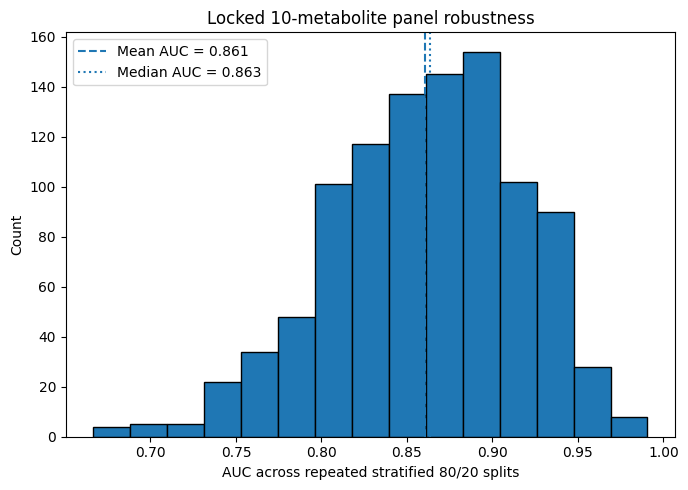

Locked 10-panel saved.
Repeated split AUC mean: 0.8607060185185185
Repeated split AUC median: 0.8634259259259259
Repeated split AUC std: 0.05523248923167125
Saved to: ../../output/consensus_metabolite_panel_clean


In [20]:
# =========================
# SAVE 10-PANEL + ROBUSTNESS EVALUATION
# =========================

LOCKED_PANEL = TRADEOFF_FEATURES
OUT_DIR = "../../output/consensus_metabolite_panel_clean"
os.makedirs(OUT_DIR, exist_ok=True)

# Save locked panel
pd.Series(LOCKED_PANEL, name="metabolite").to_csv(
    f"{OUT_DIR}/LOCKED_10_PANEL.csv",
    index=False
)

# Save coefficients
coef_10.to_csv(f"{OUT_DIR}/LOCKED_10_PANEL_COEFFICIENTS.csv")

# Repeated split robustness: fixed locked panel only
aucs = []

for seed in range(1000):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            max_iter=5000,
            random_state=seed
        ))
    ])

    model.fit(X_tr[LOCKED_PANEL], y_tr)
    probs = model.predict_proba(X_te[LOCKED_PANEL])[:, 1]
    aucs.append(roc_auc_score(y_te, probs))

robustness_summary = pd.DataFrame([{
    "panel_size": len(LOCKED_PANEL),
    "mean_repeated_split_auc": np.mean(aucs),
    "median_repeated_split_auc": np.median(aucs),
    "std_repeated_split_auc": np.std(aucs),
    "min_repeated_split_auc": np.min(aucs),
    "max_repeated_split_auc": np.max(aucs),
    "heldout_seed42_auc": roc_auc_score(y_test, test_probs),
    "features": " | ".join(LOCKED_PANEL)
}])

display(robustness_summary)

robustness_summary.to_csv(
    f"{OUT_DIR}/LOCKED_10_PANEL_REPEATED_SPLIT_ROBUSTNESS.csv",
    index=False
)

# Plot AUC distribution
plt.figure(figsize=(7, 5))
plt.hist(aucs, bins=15, edgecolor="black")
plt.axvline(np.mean(aucs), linestyle="--", label=f"Mean AUC = {np.mean(aucs):.3f}")
plt.axvline(np.median(aucs), linestyle=":", label=f"Median AUC = {np.median(aucs):.3f}")
plt.xlabel("AUC across repeated stratified 80/20 splits")
plt.ylabel("Count")
plt.title("Locked 10-metabolite panel robustness")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/LOCKED_10_PANEL_AUC_DISTRIBUTION.png", dpi=300)
plt.show()

print("Locked 10-panel saved.")
print("Repeated split AUC mean:", np.mean(aucs))
print("Repeated split AUC median:", np.median(aucs))
print("Repeated split AUC std:", np.std(aucs))
print("Saved to:", OUT_DIR)

Real AUC: 0.8530864197530864
Permutation p-value: 0.0


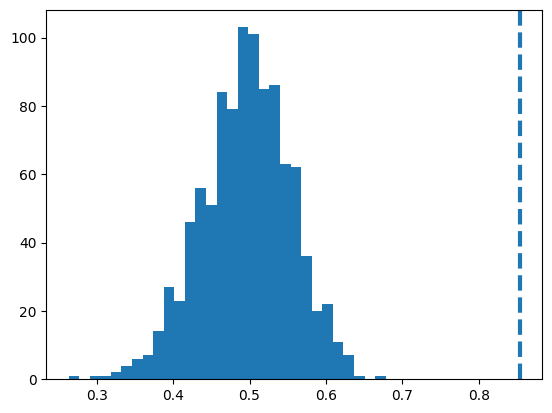

In [21]:
real_auc = cross_val_score(
    tradeoff_model,
    X[LOCKED_PANEL],
    y,
    cv=5,
    scoring="roc_auc"
).mean()

perm_aucs = []

for i in range(1000):

    y_perm = np.random.permutation(y)

    auc = cross_val_score(
        tradeoff_model,
        X[LOCKED_PANEL],
        y_perm,
        cv=5,
        scoring="roc_auc"
    ).mean()

    perm_aucs.append(auc)

perm_aucs = np.array(perm_aucs)

p_value = np.mean(perm_aucs >= real_auc)

print("Real AUC:", real_auc)
print("Permutation p-value:", p_value)

plt.hist(perm_aucs, bins=30)
plt.axvline(real_auc, linestyle="--", linewidth=3)
plt.show()

In [22]:
boot_aucs = []

rng = np.random.default_rng(42)

for _ in range(2000):

    idx = rng.choice(
        len(y_test),
        size=len(y_test),
        replace=True
    )

    if len(np.unique(y_test.iloc[idx])) < 2:
        continue

    auc = roc_auc_score(
        y_test.iloc[idx],
        test_probs[idx]
    )

    boot_aucs.append(auc)

ci_lower = np.percentile(boot_aucs, 2.5)
ci_upper = np.percentile(boot_aucs, 97.5)

print("Test AUC:", roc_auc_score(y_test, test_probs))
print("95% CI:", ci_lower, "-", ci_upper)

Test AUC: 0.8587962962962963
95% CI: 0.728475935828877 - 0.9538461538461538


In [23]:
from scipy.stats import mannwhitneyu

results = []

for m in TRADEOFF_FEATURES:

    case = X.loc[y == 1, m]
    ctrl = X.loc[y == 0, m]

    stat, p = mannwhitneyu(case, ctrl)

    results.append({
        "metabolite": m,
        "p": p
    })

pd.DataFrame(results).sort_values("p")

,metabolite,p
6,3-(4-hydroxyphenyl)lactate,0.000001
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.000016
5,N-palmitoyl-sphingosine (d18:1/16:0),0.000022
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.000025
2,N4-acetylcytidine,0.000063
1,N-acetylglutamate,0.000116
4,1-methylurate,0.000160
9,4-vinylguaiacol sulfate,0.000202
8,vanillylmandelate (VMA),0.000496
7,N-acetylglucosamine/N-acetylgalactosamine,0.001607


In [24]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

def cohens_d(x, y):

    nx, ny = len(x), len(y)

    pooled = np.sqrt(
        (
            (nx - 1) * x.var(ddof=1)
            + (ny - 1) * y.var(ddof=1)
        )
        / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled

rows = []

for m in TRADEOFF_FEATURES:

    case = X.loc[y == 1, m]
    ctrl = X.loc[y == 0, m]

    _, p = mannwhitneyu(case, ctrl)

    rows.append({
        "metabolite": m,
        "p": p,
        "cohens_d": cohens_d(case, ctrl)
    })

stats_df = pd.DataFrame(rows)

stats_df["fdr"] = multipletests(
    stats_df["p"],
    method="fdr_bh"
)[1]

stats_df = stats_df.sort_values("fdr")

display(stats_df)

,metabolite,p,cohens_d,fdr
6,3-(4-hydroxyphenyl)lactate,0.000001,-0.607446,0.000012
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.000025,0.604367,0.000062
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.000016,0.620477,0.000062
5,N-palmitoyl-sphingosine (d18:1/16:0),0.000022,0.627788,0.000062
2,N4-acetylcytidine,0.000063,0.559763,0.000126
1,N-acetylglutamate,0.000116,0.636926,0.000193
4,1-methylurate,0.000160,-0.532764,0.000228
9,4-vinylguaiacol sulfate,0.000202,-0.484969,0.000252
8,vanillylmandelate (VMA),0.000496,-0.482851,0.000551
7,N-acetylglucosamine/N-acetylgalactosamine,0.001607,0.417861,0.001607


In [25]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "metabolite": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance.head(30))

,metabolite,importance
20,3-(4-hydroxyphenyl)lactate,0.009605
334,beta-cryptoxanthin,0.009399
739,X-11847,0.009283
516,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.008480
259,N4-acetylcytidine,0.008264
737,X-11795,0.007863
380,5-(galactosylhydroxy)-lysine,0.007635
465,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.007418
138,N-acetylglutamate,0.006762
740,X-11849,0.006398


In [26]:
rf_top20 = set(rf_importance.head(20)["metabolite"])

locked_overlap = [
    m for m in TRADEOFF_FEATURES
    if m in rf_top20
]

print("Locked panel metabolites in RF top 20:")
print(len(locked_overlap), "/", len(TRADEOFF_FEATURES))

for m in locked_overlap:
    print("-", m)

Locked panel metabolites in RF top 20:
6 / 10
- 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- N-acetylglutamate
- N4-acetylcytidine
- sphingomyelin (d18:1/24:1, d18:2/24:0)*
- 1-methylurate
- 3-(4-hydroxyphenyl)lactate


In [27]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    "metabolite": X_train.columns,
    "mi": mi
}).sort_values("mi", ascending=False)

display(mi_df.head(30))

,metabolite,mi
353,"androstenediol (3beta,17beta) monosulfate (1)",0.138256
695,5-hydroxy-2-methylpyridine sulfate,0.114348
65,N-stearoyl-sphinganine (d18:0/18:0)*,0.107683
317,1-linoleoyl-GPI (18:2)*,0.106485
491,behenoyl sphingomyelin (d18:1/22:0)*,0.103949
341,"androstenediol (3beta,17beta) disulfate (2)",0.103429
326,1-stearoyl-2-arachidonoyl-GPC (18:0/20:4),0.103363
141,theobromine,0.103276
739,X-11847,0.100290
4,3-hydroxy-3-methylglutarate,0.100086


In [28]:
mi_top20 = set(mi_df.head(20)["metabolite"])

locked_overlap = [
    m for m in TRADEOFF_FEATURES
    if m in mi_top20
]

print("Locked panel metabolites in MI top 20:")
print(len(locked_overlap), "/", len(TRADEOFF_FEATURES))

for m in locked_overlap:
    print("-", m)

Locked panel metabolites in MI top 20:
1 / 10
- 1-methylurate


In [29]:
rf_top10 = rf_importance.head(10)["metabolite"].tolist()

print("RF Top 10:")
for m in rf_top10:
    print("-", m)

rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

rf_model.fit(X_train[rf_top10], y_train)

rf_probs = rf_model.predict_proba(X_test[rf_top10])[:, 1]

print("\nRF Top-10 Test AUC:")
print(roc_auc_score(y_test, rf_probs))

RF Top 10:
- 3-(4-hydroxyphenyl)lactate
- beta-cryptoxanthin
- X-11847
- 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- N4-acetylcytidine
- X-11795
- 5-(galactosylhydroxy)-lysine
- sphingomyelin (d18:1/24:1, d18:2/24:0)*
- N-acetylglutamate
- X-11849

RF Top-10 Test AUC:
0.8402777777777778


In [30]:
mi_top10 = mi_df.head(10)["metabolite"].tolist()

print("MI Top 10:")
for m in mi_top10:
    print("-", m)

mi_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

mi_model.fit(X_train[mi_top10], y_train)

mi_probs = mi_model.predict_proba(X_test[mi_top10])[:, 1]

print("\nMI Top-10 Test AUC:")
print(roc_auc_score(y_test, mi_probs))

MI Top 10:
- androstenediol (3beta,17beta) monosulfate (1)
- 5-hydroxy-2-methylpyridine sulfate
- N-stearoyl-sphinganine (d18:0/18:0)*
- 1-linoleoyl-GPI (18:2)*
- behenoyl sphingomyelin (d18:1/22:0)*
- androstenediol (3beta,17beta) disulfate (2)
- 1-stearoyl-2-arachidonoyl-GPC (18:0/20:4)
- theobromine
- X-11847
- 3-hydroxy-3-methylglutarate

MI Top-10 Test AUC:
0.6296296296296297


N-acetylglutamate                               0.646390
3-(4-hydroxyphenyl)lactate                      0.580842
vanillylmandelate (VMA)                         0.566704
N4-acetylcytidine                               0.555486
N-palmitoyl-sphingosine (d18:1/16:0)            0.461897
sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.389946
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.354654
1-methylurate                                   0.345536
N-acetylglucosamine/N-acetylgalactosamine       0.313460
4-vinylguaiacol sulfate                         0.127114
dtype: float64

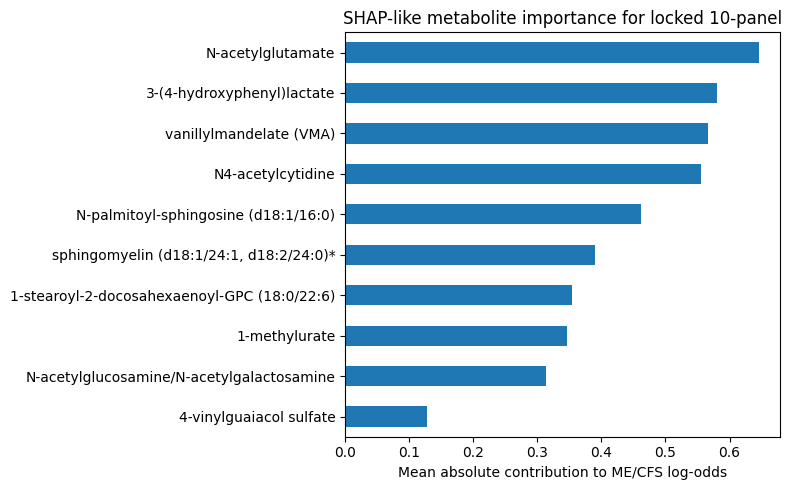

In [31]:
# =========================
# SHAP-STYLE CONTRIBUTION SCORES FOR LOGISTIC REGRESSION
# =========================
# For linear/logistic models, contribution = standardized metabolite value × coefficient

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get standardized values from final locked model
X_scaled = tradeoff_model.named_steps["scaler"].transform(
    X[TRADEOFF_FEATURES]
)

coefs = tradeoff_model.named_steps["logreg"].coef_[0]

# Contribution to log-odds for each subject/metabolite
contrib = X_scaled * coefs

shap_like_df = pd.DataFrame(
    contrib,
    columns=TRADEOFF_FEATURES
)

# Mean absolute contribution = global importance
global_importance = (
    shap_like_df
    .abs()
    .mean()
    .sort_values(ascending=False)
)

display(global_importance)

plt.figure(figsize=(8,5))
global_importance.sort_values().plot(kind="barh")
plt.xlabel("Mean absolute contribution to ME/CFS log-odds")
plt.title("SHAP-like metabolite importance for locked 10-panel")
plt.tight_layout()
plt.show()

In [32]:
print("Shape:", X[TRADEOFF_FEATURES].shape)

print("\nClass counts:")
print(y.value_counts())

print("\nMeans:")
display(
    X[TRADEOFF_FEATURES]
    .mean()
    .sort_index()
)

print("\nStds:")
display(
    X[TRADEOFF_FEATURES]
    .std()
    .sort_index()
)

Shape: (214, 10)

Class counts:
1    135
0     79
Name: study_ptorhc, dtype: int64

Means:


1-methylurate                                   0.872156
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    1.334637
3-(4-hydroxyphenyl)lactate                      0.900319
4-vinylguaiacol sulfate                         0.258056
N-acetylglucosamine/N-acetylgalactosamine       0.797387
N-acetylglutamate                               0.545900
N-palmitoyl-sphingosine (d18:1/16:0)            1.262211
N4-acetylcytidine                               2.234001
sphingomyelin (d18:1/24:1, d18:2/24:0)*         1.218902
vanillylmandelate (VMA)                         1.258182
dtype: float64


Stds:


1-methylurate                                   1.243221
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.515241
3-(4-hydroxyphenyl)lactate                      0.321833
4-vinylguaiacol sulfate                         0.647525
N-acetylglucosamine/N-acetylgalactosamine       0.258585
N-acetylglutamate                               0.210872
N-palmitoyl-sphingosine (d18:1/16:0)            0.340849
N4-acetylcytidine                               1.484297
sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.198900
vanillylmandelate (VMA)                         0.450444
dtype: float64

In [33]:
tradeoff_model.named_steps["logreg"].get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 5000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [34]:
# ==========================================
# NB1 FINAL EXPORT
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent / "MECFS_FINAL_SIGNATURES"
NB1_DIR = ROOT / "NB1_LOCKED_10_PANEL"

NB1_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------
# Panel
# ------------------------------------------

pd.DataFrame({
    "feature": TRADEOFF_FEATURES
}).to_csv(
    NB1_DIR / "01_locked_10_metabolite_panel.csv",
    index=False
)

# ------------------------------------------
# Coefficients
# ------------------------------------------

coef_10.rename("coefficient").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    NB1_DIR / "02_10_metabolite_coefficients.csv",
    index=False
)

# ------------------------------------------
# Intercept
# ------------------------------------------

pd.DataFrame({
    "intercept": [intercept_10]
}).to_csv(
    NB1_DIR / "03_10_metabolite_intercept.csv",
    index=False
)

# ------------------------------------------
# Scaler constants
# ------------------------------------------

scaler_10 = tradeoff_model.named_steps["scaler"]

pd.DataFrame({
    "feature": TRADEOFF_FEATURES,
    "mean": scaler_10.mean_,
    "scale": scaler_10.scale_
}).to_csv(
    NB1_DIR / "04_10_metabolite_scaler_constants.csv",
    index=False
)

# ------------------------------------------
# Robustness
# ------------------------------------------

robustness_summary.to_csv(
    NB1_DIR / "05_10_metabolite_robustness.csv",
    index=False
)

# ------------------------------------------
# Permutation test
# ------------------------------------------

pd.DataFrame([{
    "real_auc": real_auc,
    "null_mean_auc": np.mean(perm_aucs),
    "null_std_auc": np.std(perm_aucs),
    "permutation_p": p_value
}]).to_csv(
    NB1_DIR / "06_10_metabolite_permutation_test.csv",
    index=False
)

print("Saved:")
print(NB1_DIR)

Saved:
c:\Users\rohan\OneDrive\Desktop\ME-CFS\src\MECFS_FINAL_SIGNATURES\NB1_LOCKED_10_PANEL


In [35]:
coef_from_model = pd.Series(
    tradeoff_model.named_steps["logreg"].coef_[0],
    index=TRADEOFF_FEATURES
)

coef_from_csv = pd.read_csv(
    NB1_DIR / "02_10_metabolite_coefficients.csv"
)

print(
    np.allclose(
        coef_from_model.values,
        coef_from_csv["coefficient"].values
    )
)

False


In [36]:
from sklearn.metrics import roc_auc_score
import numpy as np
probs = test_probs
def bootstrap_auc_ci(y_true, probs, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.array(y_true)
    probs = np.array(probs)

    aucs = []

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)

        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(
            roc_auc_score(y_true[idx], probs[idx])
        )

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return np.mean(aucs), lower, upper

auc_mean, auc_low, auc_high = bootstrap_auc_ci(y_test, probs)

print(f"AUC: {roc_auc_score(y_test, probs):.3f}")
print(f"Bootstrap mean: {auc_mean:.3f}")
print(f"95% CI: [{auc_low:.3f}, {auc_high:.3f}]")

AUC: 0.859
Bootstrap mean: 0.859
95% CI: [0.729, 0.954]


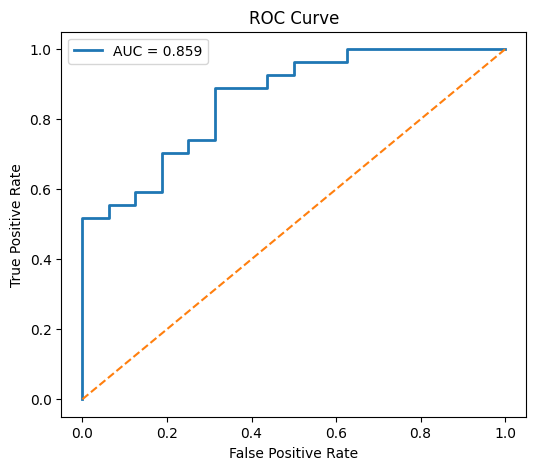

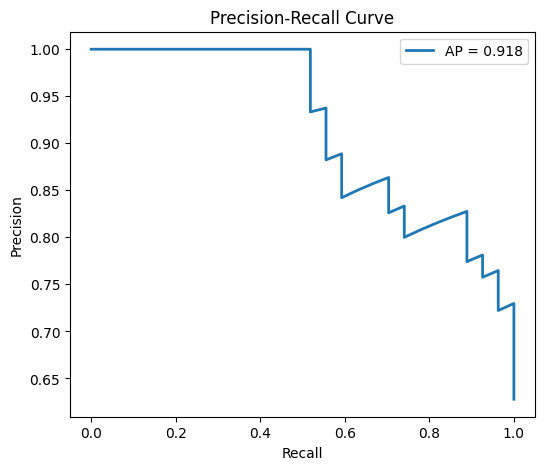

In [37]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ROC

fpr, tpr, roc_thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    probs
)

ap = average_precision_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2,
         label=f"AP = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [38]:
from sklearn.metrics import confusion_matrix

# Youden's J

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

optimal_threshold = roc_thresholds[best_idx]

y_pred = (probs >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

ppv = tp / (tp + fp)
npv = tn / (tn + fn)

accuracy = (tp + tn) / (tp + tn + fp + fn)

balanced_accuracy = (
    sensitivity + specificity
) / 2

print(f"Optimal threshold: {optimal_threshold:.3f}")
print()

print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV: {ppv:.3f}")
print(f"NPV: {npv:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced accuracy: {balanced_accuracy:.3f}")
print()

print("Confusion matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Optimal threshold: 0.581

Sensitivity: 0.889
Specificity: 0.688
PPV: 0.828
NPV: 0.786
Accuracy: 0.814
Balanced accuracy: 0.788

Confusion matrix:
TN=11, FP=5, FN=3, TP=24


In [39]:
import numpy as np
import pandas as pd

test_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

print("Controls:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].describe())

print("\nME/CFS:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].describe())

print("\nHighest control probability:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].max())

print("\nLowest ME/CFS probability:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].min())

print("\nOptimal threshold used:")
print(optimal_threshold)

Controls:
count    16.000000
mean      0.375594
std       0.334702
min       0.015972
25%       0.061965
50%       0.264660
75%       0.689418
max       0.883579
Name: prob_ME_CFS, dtype: float64

ME/CFS:
count    27.000000
mean      0.789739
std       0.228434
min       0.157262
25%       0.670702
50%       0.890764
75%       0.959585
max       0.996077
Name: prob_ME_CFS, dtype: float64

Highest control probability:
0.8835785887636798

Lowest ME/CFS probability:
0.15726244151493465

Optimal threshold used:
0.5814597238843504


In [40]:
import numpy as np
import pandas as pd

score_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

thresholds = np.arange(0.1, 1.0, 0.05)

rows = []

for low_cut in thresholds:
    for high_cut in thresholds:
        if low_cut >= high_cut:
            continue

        called_low = score_df["prob_ME_CFS"] < low_cut
        called_high = score_df["prob_ME_CFS"] > high_cut
        inconclusive = ~(called_low | called_high)

        low_group = score_df[called_low]
        high_group = score_df[called_high]

        low_correct = (low_group["y_true"] == 0).mean() if len(low_group) > 0 else np.nan
        high_correct = (high_group["y_true"] == 1).mean() if len(high_group) > 0 else np.nan

        rows.append({
            "low_cut": low_cut,
            "high_cut": high_cut,
            "n_low_called": len(low_group),
            "n_high_called": len(high_group),
            "n_inconclusive": inconclusive.sum(),
            "low_correct_rate": low_correct,
            "high_correct_rate": high_correct,
            "coverage": 1 - inconclusive.mean()
        })

range_df = pd.DataFrame(rows)

range_df.sort_values(
    ["high_correct_rate", "low_correct_rate", "coverage"],
    ascending=False
).head(20)

,low_cut,high_cut,n_low_called,n_high_called,n_inconclusive,low_correct_rate,high_correct_rate,coverage
31,0.15,0.90,6,13,24,1.000000,1.0,0.441860
15,0.10,0.90,5,13,25,1.000000,1.0,0.418605
32,0.15,0.95,6,7,30,1.000000,1.0,0.302326
16,0.10,0.95,5,7,31,1.000000,1.0,0.279070
46,0.20,0.90,8,13,22,0.875000,1.0,0.488372
60,0.25,0.90,8,13,22,0.875000,1.0,0.488372
47,0.20,0.95,8,7,28,0.875000,1.0,0.348837
61,0.25,0.95,8,7,28,0.875000,1.0,0.348837
73,0.30,0.90,11,13,19,0.818182,1.0,0.558140
85,0.35,0.90,11,13,19,0.818182,1.0,0.558140


In [41]:
print(type(scaler_10))

print("\nMeans:")
print(pd.Series(
    scaler_10.mean_,
    index=LOCKED_PANEL
))

print("\nScales:")
print(pd.Series(
    scaler_10.scale_,
    index=LOCKED_PANEL
))

<class 'sklearn.preprocessing._data.StandardScaler'>

Means:
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    1.338363
N-acetylglutamate                               0.545911
N4-acetylcytidine                               2.280075
sphingomyelin (d18:1/24:1, d18:2/24:0)*         1.220551
1-methylurate                                   0.859866
N-palmitoyl-sphingosine (d18:1/16:0)            1.240510
3-(4-hydroxyphenyl)lactate                      0.902257
N-acetylglucosamine/N-acetylgalactosamine       0.782058
vanillylmandelate (VMA)                         1.241580
4-vinylguaiacol sulfate                         0.268020
dtype: float64

Scales:
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.534510
N-acetylglutamate                               0.217290
N4-acetylcytidine                               1.529270
sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.191185
1-methylurate                                   1.259691
N-palmitoyl-sphingosine (d18:1/16:0)            0.317045
3-(

In [42]:
print(X[LOCKED_PANEL].describe().T[["mean", "std", "min", "max"]])

                                                  mean       std       min  \
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)  1.334637  0.515241  0.350749   
N-acetylglutamate                             0.545900  0.210872  0.048052   
N4-acetylcytidine                             2.234001  1.484297  0.442886   
sphingomyelin (d18:1/24:1, d18:2/24:0)*       1.218902  0.198900  0.736540   
1-methylurate                                 0.872156  1.243221  0.034227   
N-palmitoyl-sphingosine (d18:1/16:0)          1.262211  0.340849  0.661338   
3-(4-hydroxyphenyl)lactate                    0.900319  0.321833  0.378741   
N-acetylglucosamine/N-acetylgalactosamine     0.797387  0.258585  0.218331   
vanillylmandelate (VMA)                       1.258182  0.450444  0.371448   
4-vinylguaiacol sulfate                       0.258056  0.647525  0.070572   

                                                    max  
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)   3.391727  
N-acetylglutamate        

In [43]:
print(metab_raw.iloc[:5, :5])

                    Unnamed: 0  SAM000203_tp1  SAM000269_tp1  SAM000268_tp1  \
0  S-1-pyrroline-5-carboxylate       0.733745       1.476325       1.411830   
1         1-methylnicotinamide       0.382365       0.387559       1.383625   
2          alpha-ketoglutarate       0.847127       0.342713       0.350704   
3         3-hydroxyisobutyrate       0.442159       0.488864       0.187794   
4  3-hydroxy-3-methylglutarate       0.784203       0.907234       1.005262   

   SAM000266_tp1  
0       0.566404  
1       0.840769  
2       0.464346  
3       1.405387  
4       1.436603  


In [44]:
metab_raw.describe().iloc[:, :5]

,SAM000203_tp1,SAM000269_tp1,SAM000268_tp1,SAM000266_tp1,SAM000257_tp1
count,876.000000,876.000000,876.000000,876.000000,876.000000
mean,1.633175,1.553503,2.869790,2.264210,1.787721
std,10.946723,11.203723,16.730522,12.784526,11.393870
min,0.001820,0.001820,0.001820,0.001820,0.001820
25%,0.382472,0.430855,0.623676,0.580908,0.464032
50%,0.756989,0.803007,1.042024,1.097492,0.846342
75%,1.146672,1.239848,1.575427,1.659602,1.368381
max,293.977800,293.977800,293.977800,293.977800,293.977800


In [47]:
print("Panel size:", len(LOCKED_PANEL))

for i, f in enumerate(LOCKED_PANEL, start=1):
    print(i, f)

Panel size: 10
1 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
2 N-acetylglutamate
3 N4-acetylcytidine
4 sphingomyelin (d18:1/24:1, d18:2/24:0)*
5 1-methylurate
6 N-palmitoyl-sphingosine (d18:1/16:0)
7 3-(4-hydroxyphenyl)lactate
8 N-acetylglucosamine/N-acetylgalactosamine
9 vanillylmandelate (VMA)
10 4-vinylguaiacol sulfate


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X10 = X[LOCKED_PANEL]

X_train, X_test, y_train, y_test = train_test_split(
    X10,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

locked_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

locked_model.fit(X_train, y_train)

probs = locked_model.predict_proba(X_test)[:, 1]

print("Held-out AUC:", roc_auc_score(y_test, probs))

Held-out AUC: 0.8587962962962963


In [50]:
from sklearn.metrics import confusion_matrix

rows = []

for threshold in np.arange(0.05, 0.96, 0.01):

    preds = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        preds
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    rows.append({
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "sensitivity": sensitivity,
        "specificity": specificity
    })

threshold_df = pd.DataFrame(rows)

display(threshold_df.head())

,threshold,TP,FP,TN,FN,sensitivity,specificity
0,0.05,27,12,4,0,1.0,0.2500
1,0.06,27,12,4,0,1.0,0.2500
2,0.07,27,12,4,0,1.0,0.2500
3,0.08,27,11,5,0,1.0,0.3125
4,0.09,27,11,5,0,1.0,0.3125


In [51]:
screening_df = threshold_df[
    threshold_df["sensitivity"] >= 0.95
].copy()

screening_df = screening_df.sort_values(
    "specificity",
    ascending=False
)

display(screening_df.head(20))

,threshold,TP,FP,TN,FN,sensitivity,specificity
22,0.27,26,8,8,1,0.962963,0.5000
21,0.26,26,8,8,1,0.962963,0.5000
20,0.25,26,9,7,1,0.962963,0.4375
19,0.24,26,9,7,1,0.962963,0.4375
18,0.23,26,9,7,1,0.962963,0.4375
17,0.22,26,9,7,1,0.962963,0.4375
16,0.21,26,9,7,1,0.962963,0.4375
15,0.20,26,9,7,1,0.962963,0.4375
12,0.17,26,10,6,1,0.962963,0.3750
14,0.19,26,10,6,1,0.962963,0.3750


Brier score: 0.15088161210718223


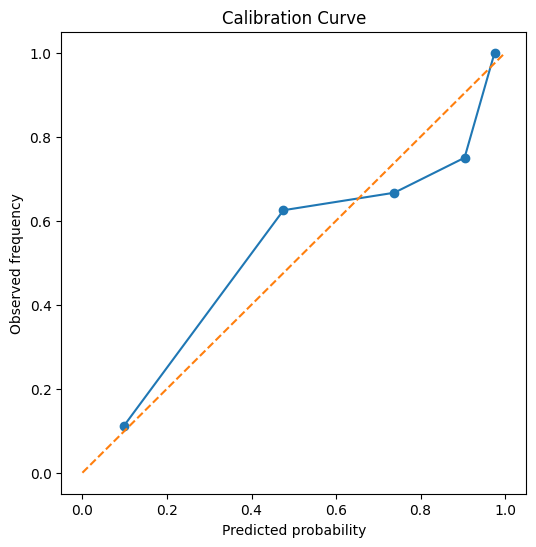

In [52]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

brier = brier_score_loss(
    y_test,
    probs
)

print("Brier score:", brier)

prob_true, prob_pred = calibration_curve(
    y_test,
    probs,
    n_bins=5,
    strategy="quantile"
)

plt.figure(figsize=(6,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")

plt.show()

In [53]:
mistakes = pd.DataFrame({
    "true_label": y_test.values,
    "predicted_probability": probs
})

mistakes["error"] = np.abs(
    mistakes["true_label"] -
    mistakes["predicted_probability"]
)

mistakes = mistakes.sort_values(
    "error",
    ascending=False
)

display(mistakes.head(20))

,true_label,predicted_probability,error
21,0,0.883579,0.883579
5,0,0.870237,0.870237
22,1,0.157262,0.842738
34,0,0.837782,0.837782
18,1,0.277684,0.722316
19,0,0.702592,0.702592
33,0,0.685026,0.685026
30,1,0.422364,0.577636
38,0,0.564188,0.564188
0,0,0.463914,0.463914


In [54]:
hard_false_negatives = pd.DataFrame(
    X_test.loc[y_test.index]
)

hard_false_negatives["true_label"] = y_test.values
hard_false_negatives["probability"] = probs

hard_false_negatives = hard_false_negatives[
    (hard_false_negatives["true_label"] == 1)
    &
    (hard_false_negatives["probability"] < 0.30)
]

print("Number of hard false negatives:")
print(len(hard_false_negatives))

display(hard_false_negatives)

Number of hard false negatives:
2


,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),N-acetylglutamate,N4-acetylcytidine,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",1-methylurate,N-palmitoyl-sphingosine (d18:1/16:0),3-(4-hydroxyphenyl)lactate,N-acetylglucosamine/N-acetylgalactosamine,vanillylmandelate (VMA),4-vinylguaiacol sulfate,true_label,probability
153,1.508145,0.547738,0.523619,1.159628,0.392648,1.091600,0.795071,0.904074,1.961741,0.451159,1,0.277684
115,1.151677,0.410085,1.769597,0.965175,0.373972,1.029392,1.002778,0.712689,1.520023,0.070572,1,0.157262


In [55]:
for feat in LOCKED_PANEL:

    print("\n", feat)

    print(
        hard_false_negatives[feat].describe()
    )

    print(
        X.loc[y == 1, feat].describe()
    )


 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
count    2.000000
mean     1.329911
std      0.252061
min      1.151677
25%      1.240794
50%      1.329911
75%      1.419028
max      1.508145
Name: 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6), dtype: float64
count    135.000000
mean       1.445212
std        0.557772
min        0.350749
25%        1.071474
50%        1.402103
75%        1.775040
max        3.391727
Name: 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6), dtype: float64

 N-acetylglutamate
count    2.000000
mean     0.478912
std      0.097335
min      0.410085
25%      0.444499
50%      0.478912
75%      0.513325
max      0.547738
Name: N-acetylglutamate, dtype: float64
count    135.000000
mean       0.593386
std        0.171881
min        0.318053
25%        0.467642
50%        0.566646
75%        0.686320
max        1.072881
Name: N-acetylglutamate, dtype: float64

 N4-acetylcytidine
count    2.000000
mean     1.146608
std      0.881039
min      0.523619
25%      0.835114
5

In [75]:
# =========================
# Locked 10 robustness + repeated error analysis + ME/CFS subtype check
# =========================

import numpy as np
import pandas as pd
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------
# Setup
# -------------------------

X10 = X[LOCKED_PANEL].copy()
y10 = y.copy()

N_SPLITS = 500
THRESHOLD = 0.5

auc_rows = []
error_counts = defaultdict(lambda: {"times_tested": 0, "FN": 0, "FP": 0, "TN": 0, "TP": 0})
prob_records = []

# -------------------------
# Repeated split robustness + error collection
# -------------------------

for seed in range(N_SPLITS):

    X_train, X_test, y_train, y_test = train_test_split(
        X10,
        y10,
        test_size=0.20,
        stratify=y10,
        random_state=seed
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= THRESHOLD).astype(int)

    auc = roc_auc_score(y_test, probs)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    auc_rows.append({
        "seed": seed,
        "auc": auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp)
    })

    for idx, true, pred, prob in zip(y_test.index, y_test.values, preds, probs):
        error_counts[idx]["times_tested"] += 1

        if true == 1 and pred == 1:
            error_counts[idx]["TP"] += 1
        elif true == 1 and pred == 0:
            error_counts[idx]["FN"] += 1
        elif true == 0 and pred == 0:
            error_counts[idx]["TN"] += 1
        elif true == 0 and pred == 1:
            error_counts[idx]["FP"] += 1

        prob_records.append({
            "seed": seed,
            "index": idx,
            "true_label": true,
            "prob_ME_CFS": prob,
            "pred": pred
        })

robust_df = pd.DataFrame(auc_rows)
prob_df = pd.DataFrame(prob_records)

error_df = pd.DataFrame.from_dict(error_counts, orient="index")
error_df.index.name = "index"
error_df = error_df.reset_index()

error_df["true_label"] = error_df["index"].map(y10)
error_df["FN_rate_when_tested"] = error_df["FN"] / error_df["times_tested"]
error_df["FP_rate_when_tested"] = error_df["FP"] / error_df["times_tested"]

prob_summary = (
    prob_df.groupby("index")["prob_ME_CFS"]
    .agg(mean_prob="mean", median_prob="median", std_prob="std", min_prob="min", max_prob="max")
    .reset_index()
)

error_df = error_df.merge(prob_summary, on="index", how="left")

print("===== LOCKED 10 ROBUSTNESS =====")
print("Mean AUC:", robust_df["auc"].mean())
print("Median AUC:", robust_df["auc"].median())
print("Std AUC:", robust_df["auc"].std())
print("5th pct AUC:", robust_df["auc"].quantile(0.05))
print("95th pct AUC:", robust_df["auc"].quantile(0.95))
print("Mean FN:", robust_df["FN"].mean())
print("Mean FP:", robust_df["FP"].mean())
print("Mean sensitivity:", robust_df["sensitivity"].mean())
print("Mean specificity:", robust_df["specificity"].mean())

print("\n===== MOST REPEATED FALSE NEGATIVES =====")
display(
    error_df[error_df["true_label"] == 1]
    .sort_values("FN_rate_when_tested", ascending=False)
    .head(20)
)

print("\n===== MOST REPEATED FALSE POSITIVES =====")
display(
    error_df[error_df["true_label"] == 0]
    .sort_values("FP_rate_when_tested", ascending=False)
    .head(20)
)

# -------------------------
# Attach locked-panel metabolite values to error table
# -------------------------

error_with_metabs = error_df.merge(
    X10.reset_index().rename(columns={"index": "index"}),
    on="index",
    how="left"
)

print("\n===== HARD FALSE NEGATIVES WITH METABOLITES =====")
display(
    error_with_metabs[
        (error_with_metabs["true_label"] == 1) &
        (error_with_metabs["FN_rate_when_tested"] >= 0.5)
    ].sort_values("FN_rate_when_tested", ascending=False)
)

# -------------------------
# ME/CFS-only clustering / subtype exploration
# -------------------------

case_idx = y10[y10 == 1].index
X_cases = X10.loc[case_idx].copy()

scaler = StandardScaler()
X_cases_scaled = scaler.fit_transform(X_cases)

pca = PCA(n_components=2, random_state=42)
case_pcs = pca.fit_transform(X_cases_scaled)

cluster_rows = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_cases_scaled)

    sil = silhouette_score(X_cases_scaled, labels)

    cluster_rows.append({
        "k": k,
        "silhouette": sil
    })

cluster_df = pd.DataFrame(cluster_rows)
display(cluster_df)

best_k = int(cluster_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

km = KMeans(n_clusters=best_k, random_state=42, n_init=50)
case_clusters = km.fit_predict(X_cases_scaled)

case_subtype_df = pd.DataFrame({
    "index": case_idx,
    "cluster": case_clusters,
    "PC1": case_pcs[:, 0],
    "PC2": case_pcs[:, 1]
})

case_subtype_df = case_subtype_df.merge(
    error_df[["index", "true_label", "times_tested", "FN", "FN_rate_when_tested", "mean_prob", "median_prob"]],
    on="index",
    how="left"
)

print("\n===== CASE CLUSTERS + FALSE NEGATIVE BURDEN =====")
display(
    case_subtype_df
    .groupby("cluster")
    .agg(
        n_cases=("index", "count"),
        mean_FN_rate=("FN_rate_when_tested", "mean"),
        median_FN_rate=("FN_rate_when_tested", "median"),
        mean_prob=("mean_prob", "mean"),
        median_prob=("median_prob", "median")
    )
    .sort_values("mean_FN_rate", ascending=False)
)

print("\n===== HARD FALSE NEGATIVES WITH CLUSTERS =====")
display(
    case_subtype_df
    .sort_values("FN_rate_when_tested", ascending=False)
    .head(20)
)

===== LOCKED 10 ROBUSTNESS =====
Mean AUC: 0.859013888888889
Median AUC: 0.8611111111111112
Std AUC: 0.056037322298458474
5th pct AUC: 0.7569444444444445
95th pct AUC: 0.9421296296296297
Mean FN: 3.484
Mean FP: 4.84
Mean sensitivity: 0.8709629629629629
Mean specificity: 0.6975

===== MOST REPEATED FALSE NEGATIVES =====


,index,times_tested,FN,FP,TN,TP,true_label,FN_rate_when_tested,FP_rate_when_tested,mean_prob,median_prob,std_prob,min_prob,max_prob
89,164,105,105,0,0,0,1,1.000000,0.0,0.304520,0.302210,0.053172,0.172658,0.426582
162,153,116,116,0,0,0,1,1.000000,0.0,0.203552,0.198072,0.046045,0.101994,0.329535
8,187,105,105,0,0,0,1,1.000000,0.0,0.114783,0.106669,0.035889,0.035454,0.211116
114,115,120,120,0,0,0,1,1.000000,0.0,0.141335,0.140449,0.023108,0.086870,0.203925
141,97,93,93,0,0,0,1,1.000000,0.0,0.119289,0.116901,0.044323,0.039105,0.258670
23,71,109,108,0,0,1,1,0.990826,0.0,0.354519,0.348001,0.057254,0.205320,0.503569
195,107,99,97,0,0,2,1,0.979798,0.0,0.387236,0.381431,0.053667,0.267269,0.530530
87,193,101,97,0,0,4,1,0.960396,0.0,0.378088,0.380016,0.078249,0.186048,0.582894
191,119,98,94,0,0,4,1,0.959184,0.0,0.404291,0.399237,0.057867,0.300223,0.560203
71,10,100,92,0,0,8,1,0.920000,0.0,0.435672,0.432867,0.043535,0.339670,0.547305



===== MOST REPEATED FALSE POSITIVES =====


,index,times_tested,FN,FP,TN,TP,true_label,FN_rate_when_tested,FP_rate_when_tested,mean_prob,median_prob,std_prob,min_prob,max_prob
1,73,109,0,109,0,0,0,0.0,1.000000,0.907174,0.909873,0.032232,0.772876,0.967380
29,142,89,0,89,0,0,0,0.0,1.000000,0.804884,0.806998,0.040926,0.694008,0.876339
62,152,96,0,96,0,0,0,0.0,1.000000,0.887887,0.890748,0.028128,0.798831,0.955414
95,149,92,0,92,0,0,0,0.0,1.000000,0.941825,0.943639,0.019478,0.887634,0.975776
105,131,96,0,96,0,0,0,0.0,1.000000,0.758579,0.760477,0.039958,0.664177,0.857447
3,144,98,0,98,0,0,0,0.0,1.000000,0.837808,0.836498,0.034914,0.685158,0.935958
111,46,102,0,102,0,0,0,0.0,1.000000,0.700320,0.703604,0.035297,0.598018,0.784319
41,196,103,0,103,0,0,0,0.0,1.000000,0.819152,0.820245,0.037691,0.713926,0.915275
142,176,101,0,101,0,0,0,0.0,1.000000,0.789852,0.789026,0.045561,0.682407,0.885554
80,138,88,0,88,0,0,0,0.0,1.000000,0.875055,0.885185,0.050734,0.723069,0.946671



===== HARD FALSE NEGATIVES WITH METABOLITES =====


...

,k,silhouette
0,2,0.196211
1,3,0.213314
2,4,0.125386
3,5,0.134296
4,6,0.134107



===== CASE CLUSTERS + FALSE NEGATIVE BURDEN =====


,n_cases,mean_FN_rate,median_FN_rate,mean_prob,median_prob
cluster,,,,,
0,5,0.228396,0.045455,0.551431,0.667361
2,93,0.147217,0.000000,0.748537,0.826413
1,37,0.063934,0.000000,0.877769,0.948759



===== HARD FALSE NEGATIVES WITH CLUSTERS =====


,index,cluster,PC1,PC2,true_label,times_tested,FN,FN_rate_when_tested,mean_prob,median_prob
67,97,2,-0.816056,1.212749,1,93,93,1.000000,0.119289,0.116901
124,187,0,-1.796161,-1.661911,1,105,105,1.000000,0.114783,0.106669
111,164,2,-0.247931,-0.780742,1,105,105,1.000000,0.304520,0.302210
80,115,2,-0.909332,-0.719352,1,120,120,1.000000,0.141335,0.140449
102,153,2,-0.342680,-0.012862,1,116,116,1.000000,0.203552,0.198072
50,71,1,1.419998,-1.556260,1,109,108,0.990826,0.354519,0.348001
73,107,2,-0.202841,0.301868,1,99,97,0.979798,0.387236,0.381431
129,193,2,-0.755379,-2.727857,1,101,97,0.960396,0.378088,0.380016
83,119,2,-0.011043,-0.584320,1,98,94,0.959184,0.404291,0.399237
6,10,2,-1.741676,-0.608684,1,100,92,0.920000,0.435672,0.432867


In [76]:
# =========================
# Hard-FN phenotype discovery across ALL metabolites
# =========================

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

hard_fn_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] >= 0.80)
]["index"].tolist()

easy_case_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] == 0)
]["index"].tolist()

print("Hard FN cases:", len(hard_fn_idx))
print("Easy detected cases:", len(easy_case_idx))

rows = []

for feat in X.columns:
    a = X.loc[hard_fn_idx, feat].dropna()
    b = X.loc[easy_case_idx, feat].dropna()

    if len(a) < 3 or len(b) < 3:
        continue

    stat, p = mannwhitneyu(a, b, alternative="two-sided")

    d = (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

    rows.append({
        "metabolite": feat,
        "hard_FN_mean": a.mean(),
        "easy_case_mean": b.mean(),
        "difference": a.mean() - b.mean(),
        "cohens_d": d,
        "p": p
    })

fn_signature = pd.DataFrame(rows)
fn_signature["fdr"] = multipletests(fn_signature["p"], method="fdr_bh")[1]

display(
    fn_signature.sort_values("p").head(40)
)

display(
    fn_signature.sort_values("cohens_d").head(20)
)

display(
    fn_signature.sort_values("cohens_d", ascending=False).head(20)
)

Hard FN cases: 13
Easy detected cases: 97


,metabolite,hard_FN_mean,easy_case_mean,difference,cohens_d,p,fdr
50,2'-deoxyuridine,1.961986,1.383361,0.578625,1.200666,0.000434,0.148597
54,tryptophan,1.168137,0.985956,0.182181,1.189487,0.000516,0.148597
248,isovalerylcarnitine (C5),1.407359,0.968512,0.438847,1.028509,0.000572,0.148597
455,N-methylpipecolate,3.977450,2.021616,1.955834,0.976865,0.000679,0.148597
464,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",1.503681,2.232658,-0.728977,-1.070985,0.001046,0.151655
865,X-25265,1.262593,1.152532,0.110061,1.136562,0.001117,0.151655
383,hydantoin-5-propionate,1.382100,0.992013,0.390087,0.720980,0.001494,0.151655
547,N-palmitoyl-sphinganine (d18:0/16:0),0.992414,1.402146,-0.409732,-0.862457,0.001494,0.151655
426,N-acetylcarnosine,1.738428,1.079371,0.659057,0.906187,0.001617,0.151655
85,vanillylmandelate (VMA),1.571828,1.097725,0.474103,0.832494,0.002389,0.151655


,metabolite,hard_FN_mean,easy_case_mean,difference,cohens_d,p,fdr
464,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",1.503681,2.232658,-0.728977,-1.070985,0.001046,0.151655
608,sphingomyelin (d18:2/23:1)*,1.191430,1.649097,-0.457667,-0.997671,0.002619,0.151655
607,"sphingomyelin (d18:2/21:0, d16:2/23:0)*",1.564437,2.093022,-0.528585,-0.968156,0.003754,0.151655
838,X-23782,0.902133,1.413793,-0.511660,-0.950993,0.003982,0.151655
66,caproate (6:0),0.636395,0.819648,-0.183253,-0.886524,0.003236,0.151655
515,1-palmitoyl-2-docosahexaenoyl-GPC (16:0/22:6),1.178941,1.528115,-0.349174,-0.871598,0.006669,0.201451
547,N-palmitoyl-sphinganine (d18:0/16:0),0.992414,1.402146,-0.409732,-0.862457,0.001494,0.151655
141,theobromine,0.614190,3.174305,-2.560114,-0.839689,0.008699,0.204042
525,"sphingomyelin (d18:2/23:0, d18:1/23:1, d17:1/2...",1.536295,1.941030,-0.404735,-0.831196,0.013429,0.226011
873,X-25520,0.579472,1.219703,-0.640231,-0.825897,0.003698,0.151655


,metabolite,hard_FN_mean,easy_case_mean,difference,cohens_d,p,fdr
50,2'-deoxyuridine,1.961986,1.383361,0.578625,1.200666,0.000434,0.148597
54,tryptophan,1.168137,0.985956,0.182181,1.189487,0.000516,0.148597
865,X-25265,1.262593,1.152532,0.110061,1.136562,0.001117,0.151655
248,isovalerylcarnitine (C5),1.407359,0.968512,0.438847,1.028509,0.000572,0.148597
455,N-methylpipecolate,3.977450,2.021616,1.955834,0.976865,0.000679,0.148597
426,N-acetylcarnosine,1.738428,1.079371,0.659057,0.906187,0.001617,0.151655
70,xanthine,1.633986,1.251811,0.382176,0.879739,0.003236,0.151655
154,isovalerate (i5:0),1.375887,0.996113,0.379774,0.872925,0.003140,0.151655
264,5-methyluridine (ribothymidine),1.432890,1.262610,0.170281,0.838463,0.008094,0.204042
85,vanillylmandelate (VMA),1.571828,1.097725,0.474103,0.832494,0.002389,0.151655


In [77]:
# =========================
# Rescue model: can hard-FN markers detect missed ME/CFS phenotype?
# =========================

RESCUE_FEATURES = [
    "2'-deoxyuridine",
    "tryptophan",
    "isovalerylcarnitine (C5)",
    "N-methylpipecolate",
    "sphingomyelin (d18:2/14:0, d18:1/14:1)*",
    "N-palmitoyl-sphinganine (d18:0/16:0)",
    "N-acetylcarnosine",
    "vanillylmandelate (VMA)",
    "docosahexaenoate (DHA; 22:6n3)",
    "sphingomyelin (d18:2/23:1)*"
]

RESCUE_FEATURES = [f for f in RESCUE_FEATURES if f in X.columns]

print("Rescue features:")
for f in RESCUE_FEATURES:
    print("-", f)

# Label hard-FN-like ME/CFS as 1, easy-detected ME/CFS as 0
subtype_idx = hard_fn_idx + easy_case_idx

X_sub = X.loc[subtype_idx, RESCUE_FEATURES]
y_sub = pd.Series(
    [1 if idx in hard_fn_idx else 0 for idx in subtype_idx],
    index=subtype_idx
)

print("Subtype class counts:")
print(y_sub.value_counts())

# repeated CV because n=13 hard-FN is small
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

subtype_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    subtype_model,
    X_sub,
    y_sub,
    scoring="roc_auc",
    cv=cv
)

print("Hard-FN subtype CV AUC:", scores.mean(), "+/-", scores.std())
print(scores)

Rescue features:
- 2'-deoxyuridine
- tryptophan
- isovalerylcarnitine (C5)
- N-methylpipecolate
- sphingomyelin (d18:2/14:0, d18:1/14:1)*
- N-palmitoyl-sphinganine (d18:0/16:0)
- N-acetylcarnosine
- vanillylmandelate (VMA)
- docosahexaenoate (DHA; 22:6n3)
- sphingomyelin (d18:2/23:1)*
Subtype class counts:
0    97
1    13
dtype: int64
Hard-FN subtype CV AUC: 0.9424561403508772 +/- 0.04977589048548154
[0.9122807 1.        1.        0.875     0.925    ]


In [79]:
# =========================
# Honest rescue-model robustness
# Train-only discovery of hard-FN phenotype, then held-out test
# =========================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

N_SPLITS = 100
DISCOVERY_THRESHOLD = 0.5
HARD_FN_PROB_CUT = 0.50
EASY_CASE_PROB_CUT = 0.80
TOP_N_RESCUE_FEATURES = 10

rows = []

for seed in range(N_SPLITS):

    # -------------------------
    # 1. Split all subjects 80/20
    # -------------------------
    train_idx, test_idx = train_test_split(
        X.index,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    X_train_all = X.loc[train_idx].copy()
    X_test_all = X.loc[test_idx].copy()
    y_train = y.loc[train_idx].copy()
    y_test = y.loc[test_idx].copy()

    # -------------------------
    # 2. Fit locked 10-panel model on train only
    # -------------------------
    main_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    main_model.fit(X_train_all[LOCKED_PANEL], y_train)

    train_probs = pd.Series(
        main_model.predict_proba(X_train_all[LOCKED_PANEL])[:, 1],
        index=train_idx
    )

    test_probs = pd.Series(
        main_model.predict_proba(X_test_all[LOCKED_PANEL])[:, 1],
        index=test_idx
    )

    # -------------------------
    # 3. Define hard-FN-like and easy-case groups in TRAIN only
    # -------------------------
    train_case_idx = y_train[y_train == 1].index

    train_hard_fn_idx = train_case_idx[
        train_probs.loc[train_case_idx] < HARD_FN_PROB_CUT
    ]

    train_easy_case_idx = train_case_idx[
        train_probs.loc[train_case_idx] >= EASY_CASE_PROB_CUT
    ]

    # skip if too few examples
    if len(train_hard_fn_idx) < 5 or len(train_easy_case_idx) < 15:
        continue

    # -------------------------
    # 4. Find rescue markers using TRAIN only
    # -------------------------
    stat_rows = []

    for feat in X.columns:
        a = X_train_all.loc[train_hard_fn_idx, feat].dropna()
        b = X_train_all.loc[train_easy_case_idx, feat].dropna()

        if len(a) < 5 or len(b) < 15:
            continue

        stat, p = mannwhitneyu(a, b, alternative="two-sided")

        pooled_sd = np.sqrt((a.var() + b.var()) / 2)
        d = 0 if pooled_sd == 0 else (a.mean() - b.mean()) / pooled_sd

        stat_rows.append({
            "feature": feat,
            "p": p,
            "abs_d": abs(d),
            "cohens_d": d
        })

    stat_df = pd.DataFrame(stat_rows)

    if len(stat_df) == 0:
        continue

    stat_df["fdr"] = multipletests(stat_df["p"], method="fdr_bh")[1]

    rescue_features = (
        stat_df
        .sort_values(["p", "abs_d"], ascending=[True, False])
        .head(TOP_N_RESCUE_FEATURES)["feature"]
        .tolist()
    )

    # -------------------------
    # 5. Train rescue phenotype model on TRAIN only
    # Label: hard-FN-like case = 1, easy-detected case = 0
    # -------------------------
    subtype_train_idx = list(train_hard_fn_idx) + list(train_easy_case_idx)

    X_sub_train = X_train_all.loc[subtype_train_idx, rescue_features]
    y_sub_train = pd.Series(
        [1 if idx in train_hard_fn_idx else 0 for idx in subtype_train_idx],
        index=subtype_train_idx
    )

    rescue_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=seed
        ))
    ])

    rescue_model.fit(X_sub_train, y_sub_train)

    # -------------------------
    # 6. Build HELD-OUT subtype labels using main-model behavior on TEST
    # hard-FN-like test case = true ME/CFS with low main probability
    # easy-case test case = true ME/CFS with high main probability
    # -------------------------
    test_case_idx = y_test[y_test == 1].index

    test_hard_fn_idx = test_case_idx[
        test_probs.loc[test_case_idx] < HARD_FN_PROB_CUT
    ]

    test_easy_case_idx = test_case_idx[
        test_probs.loc[test_case_idx] >= EASY_CASE_PROB_CUT
    ]

    if len(test_hard_fn_idx) < 2 or len(test_easy_case_idx) < 5:
        continue

    subtype_test_idx = list(test_hard_fn_idx) + list(test_easy_case_idx)

    X_sub_test = X_test_all.loc[subtype_test_idx, rescue_features]
    y_sub_test = pd.Series(
        [1 if idx in test_hard_fn_idx else 0 for idx in subtype_test_idx],
        index=subtype_test_idx
    )

    rescue_probs = rescue_model.predict_proba(X_sub_test)[:, 1]
    rescue_auc = roc_auc_score(y_sub_test, rescue_probs)

    rows.append({
        "seed": seed,
        "rescue_auc": rescue_auc,
        "n_train_hard_fn": len(train_hard_fn_idx),
        "n_train_easy": len(train_easy_case_idx),
        "n_test_hard_fn": len(test_hard_fn_idx),
        "n_test_easy": len(test_easy_case_idx),
        "rescue_features": " | ".join(rescue_features)
    })

rescue_robustness = pd.DataFrame(rows)

print("Completed valid splits:", len(rescue_robustness), "/", N_SPLITS)

print("Mean rescue AUC:", rescue_robustness["rescue_auc"].mean())
print("Median rescue AUC:", rescue_robustness["rescue_auc"].median())
print("Std rescue AUC:", rescue_robustness["rescue_auc"].std())
print("5th pct:", rescue_robustness["rescue_auc"].quantile(0.05))
print("95th pct:", rescue_robustness["rescue_auc"].quantile(0.95))

display(rescue_robustness.describe())
display(rescue_robustness.sort_values("rescue_auc", ascending=False).head(20))

Completed valid splits: 87 / 100
Mean rescue AUC: 0.7968707479424051
Median rescue AUC: 0.8229166666666667
Std rescue AUC: 0.1444215549993917
5th pct: 0.5576388888888889
95th pct: 1.0


,seed,rescue_auc,n_train_hard_fn,n_train_easy,n_test_hard_fn,n_test_easy
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,48.528736,0.796871,10.632184,65.160920,4.080460,15.379310
std,28.858048,0.144422,1.752838,3.165488,1.699647,2.534604
min,0.000000,0.333333,6.000000,59.000000,2.000000,9.000000
25%,24.500000,0.685417,10.000000,63.000000,3.000000,13.500000
50%,49.000000,0.822917,11.000000,65.000000,4.000000,15.000000
75%,73.500000,0.905506,12.000000,67.000000,5.000000,17.000000
max,98.000000,1.000000,14.000000,74.000000,11.000000,21.000000


,seed,rescue_auc,n_train_hard_fn,n_train_easy,n_test_hard_fn,n_test_easy,rescue_features
58,66,1.000000,9,69,5,14,N-palmitoyl-sphinganine (d18:0/16:0) | tricosa...
82,93,1.000000,10,68,3,17,N-palmitoyl-sphinganine (d18:0/16:0) | tricosa...
25,28,1.000000,11,67,4,12,tryptophan | N-palmitoyl-sphinganine (d18:0/16...
53,60,1.000000,13,65,3,12,N-palmitoyl-sphinganine (d18:0/16:0) | tryptop...
56,64,1.000000,12,67,3,15,tryptophan | X-11483 | X-25265 | 2'-deoxyuridi...
23,26,1.000000,11,65,2,15,N-palmitoyl-sphinganine (d18:0/16:0) | tryptop...
62,71,1.000000,12,64,3,14,tryptophan | vanillylmandelate (VMA) | X-12544...
20,22,0.970588,12,62,2,17,N-palmitoyl-sphinganine (d18:0/16:0) | tryptop...
61,70,0.964912,11,63,3,19,N-palmitoyl-sphinganine (d18:0/16:0) | X-23782...
73,82,0.958333,13,67,6,12,N-palmitoyl-sphinganine (d18:0/16:0) | tryptop...


In [80]:
from collections import Counter

counter = Counter()

for feats in rescue_robustness["rescue_features"]:
    for f in feats.split(" | "):
        counter[f] += 1

stable_rescue = (
    pd.DataFrame({
        "feature": list(counter.keys()),
        "count": list(counter.values())
    })
    .sort_values("count", ascending=False)
)

display(stable_rescue.head(30))

,feature,count
1,N-palmitoyl-sphinganine (d18:0/16:0),75
10,tryptophan,57
0,1-stearoyl-2-docosahexaenoyl-GPE (18:0/22:6)*,44
3,tricosanoyl sphingomyelin (d18:1/23:0)*,44
9,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",32
11,2'-deoxyuridine,31
15,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",30
16,sphingomyelin (d18:2/23:1)*,29
19,4-vinylguaiacol sulfate,29
21,1-stearoyl-2-oleoyl-GPC (18:0/18:1),28


In [82]:
# =========================
# Hard-FN vs Easy ME/CFS phenotype comparison
# across available data tables
# =========================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

# -------------------------
# 1. Define groups
# -------------------------

hard_fn_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] >= 0.80)
]["index"].tolist()

easy_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] <= 0.05)
]["index"].tolist()

print("Hard-FN ME/CFS:", len(hard_fn_idx))
print("Easy-detected ME/CFS:", len(easy_idx))

# -------------------------
# 2. Collect available dataframes
# -------------------------

candidate_tables = {}

for name in [
    "X", "X10", "X_multi", "df", "meta_tp1", "meta_raw",
    "quest", "quest_df", "immune", "immune_df",
    "kegg", "kegg_df", "species", "species_df"
]:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame):
            candidate_tables[name] = obj

print("\nAvailable tables:")
for k, v in candidate_tables.items():
    print(k, v.shape)

# -------------------------
# 3. Helper function
# -------------------------

def compare_groups(table, table_name, hard_idx, easy_idx):
    results = []

    shared_hard = [i for i in hard_idx if i in table.index]
    shared_easy = [i for i in easy_idx if i in table.index]

    if len(shared_hard) < 3 or len(shared_easy) < 3:
        return pd.DataFrame()

    for col in table.columns:
        s = table[col]

        # numeric comparison
        if pd.api.types.is_numeric_dtype(s):
            a = table.loc[shared_hard, col].dropna()
            b = table.loc[shared_easy, col].dropna()

            if len(a) < 3 or len(b) < 3:
                continue

            try:
                stat, p = mannwhitneyu(a, b, alternative="two-sided")
            except Exception:
                continue

            pooled_sd = np.sqrt((a.var() + b.var()) / 2)
            d = np.nan if pooled_sd == 0 else (a.mean() - b.mean()) / pooled_sd

            results.append({
                "table": table_name,
                "feature": col,
                "type": "numeric",
                "hard_FN_mean": a.mean(),
                "easy_mean": b.mean(),
                "difference": a.mean() - b.mean(),
                "cohens_d": d,
                "p": p,
                "n_hard": len(a),
                "n_easy": len(b)
            })

        # categorical comparison
        else:
            vals = table.loc[shared_hard + shared_easy, col].dropna()

            if vals.nunique() < 2 or vals.nunique() > 10:
                continue

            for level in vals.unique():
                hard_yes = (table.loc[shared_hard, col] == level).sum()
                hard_no = len(shared_hard) - hard_yes
                easy_yes = (table.loc[shared_easy, col] == level).sum()
                easy_no = len(shared_easy) - easy_yes

                try:
                    _, p = fisher_exact([[hard_yes, hard_no], [easy_yes, easy_no]])
                except Exception:
                    continue

                results.append({
                    "table": table_name,
                    "feature": f"{col} == {level}",
                    "type": "categorical",
                    "hard_FN_mean": hard_yes / len(shared_hard),
                    "easy_mean": easy_yes / len(shared_easy),
                    "difference": (hard_yes / len(shared_hard)) - (easy_yes / len(shared_easy)),
                    "cohens_d": np.nan,
                    "p": p,
                    "n_hard": len(shared_hard),
                    "n_easy": len(shared_easy)
                })

    out = pd.DataFrame(results)

    if len(out) > 0:
        out["fdr"] = multipletests(out["p"], method="fdr_bh")[1]

    return out

# -------------------------
# 4. Run comparisons
# -------------------------

all_results = []

for table_name, table in candidate_tables.items():
    res = compare_groups(table, table_name, hard_fn_idx, easy_idx)
    if len(res) > 0:
        all_results.append(res)

phenotype_results = pd.concat(all_results, ignore_index=True)

print("\nTotal tested features:", len(phenotype_results))

# -------------------------
# 5. Display strongest differences
# -------------------------

print("\n===== Top differences by p-value =====")
display(
    phenotype_results
    .sort_values("p")
    .head(50)
)

print("\n===== Strongest higher in hard-FN group =====")
display(
    phenotype_results
    .sort_values("cohens_d", ascending=False)
    .head(30)
)

print("\n===== Strongest lower in hard-FN group =====")
display(
    phenotype_results
    .sort_values("cohens_d", ascending=True)
    .head(30)
)

print("\n===== FDR-significant results, if any =====")
display(
    phenotype_results[
        phenotype_results["fdr"] < 0.10
    ].sort_values("fdr")
)

Hard-FN ME/CFS: 13
Easy-detected ME/CFS: 108

Available tables:
X (214, 876)
X10 (214, 10)
df (214, 901)
meta_tp1 (249, 23)
meta_raw (515, 23)

Total tested features: 1846

===== Top differences by p-value =====


,table,feature,type,hard_FN_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr
50,X,2'-deoxyuridine,numeric,1.961986,1.377221,0.584765,1.196825,0.000381,13,108,0.135294
936,df,2'-deoxyuridine,numeric,1.961986,1.377221,0.584765,1.196825,0.000381,13,108,0.139309
248,X,isovalerylcarnitine (C5),numeric,1.407359,0.968376,0.438983,1.042897,0.000475,13,108,0.135294
1134,df,isovalerylcarnitine (C5),numeric,1.407359,0.968376,0.438983,1.042897,0.000475,13,108,0.139309
1751,df,X-25265,numeric,1.262593,1.145183,0.117411,1.218956,0.000522,13,108,0.139309
865,X,X-25265,numeric,1.262593,1.145183,0.117411,1.218956,0.000522,13,108,0.135294
940,df,tryptophan,numeric,1.168137,0.993252,0.174885,1.136735,0.000689,13,108,0.139309
54,X,tryptophan,numeric,1.168137,0.993252,0.174885,1.136735,0.000689,13,108,0.135294
464,X,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",numeric,1.503681,2.252830,-0.749149,-1.099705,0.000802,13,108,0.135294
1350,df,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",numeric,1.503681,2.252830,-0.749149,-1.099705,0.000802,13,108,0.139309



===== Strongest higher in hard-FN group =====


,table,feature,type,hard_FN_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr
865,X,X-25265,numeric,1.262593,1.145183,0.117411,1.218956,0.000522,13,108,0.135294
1751,df,X-25265,numeric,1.262593,1.145183,0.117411,1.218956,0.000522,13,108,0.139309
50,X,2'-deoxyuridine,numeric,1.961986,1.377221,0.584765,1.196825,0.000381,13,108,0.135294
936,df,2'-deoxyuridine,numeric,1.961986,1.377221,0.584765,1.196825,0.000381,13,108,0.139309
940,df,tryptophan,numeric,1.168137,0.993252,0.174885,1.136735,0.000689,13,108,0.139309
54,X,tryptophan,numeric,1.168137,0.993252,0.174885,1.136735,0.000689,13,108,0.135294
1134,df,isovalerylcarnitine (C5),numeric,1.407359,0.968376,0.438983,1.042897,0.000475,13,108,0.139309
248,X,isovalerylcarnitine (C5),numeric,1.407359,0.968376,0.438983,1.042897,0.000475,13,108,0.135294
1793,meta_tp1,age,numeric,57.000000,46.326531,10.673469,0.975503,0.133859,4,49,0.899232
1312,df,N-acetylcarnosine,numeric,1.738428,1.055294,0.683134,0.941583,0.001081,13,108,0.139309



===== Strongest lower in hard-FN group =====


,table,feature,type,hard_FN_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr
1806,meta_tp1,diet_grains,numeric,1.750000,3.061224,-1.311224,-1.348127,0.023250,4,49,0.627755
464,X,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",numeric,1.503681,2.252830,-0.749149,-1.099705,0.000802,13,108,0.135294
1350,df,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",numeric,1.503681,2.252830,-0.749149,-1.099705,0.000802,13,108,0.139309
1493,df,"sphingomyelin (d18:2/21:0, d16:2/23:0)*",numeric,1.564437,2.087143,-0.522706,-0.966681,0.003535,13,108,0.165748
607,X,"sphingomyelin (d18:2/21:0, d16:2/23:0)*",numeric,1.564437,2.087143,-0.522706,-0.966681,0.003535,13,108,0.172468
608,X,sphingomyelin (d18:2/23:1)*,numeric,1.191430,1.628369,-0.436939,-0.940391,0.004855,13,108,0.172468
1494,df,sphingomyelin (d18:2/23:1)*,numeric,1.191430,1.628369,-0.436939,-0.940391,0.004855,13,108,0.165748
1724,df,X-23782,numeric,0.902133,1.388719,-0.486586,-0.904650,0.007873,13,108,0.202888
838,X,X-23782,numeric,0.902133,1.388719,-0.486586,-0.904650,0.007873,13,108,0.208982
1804,meta_tp1,diet_sugar,numeric,2.000000,3.040816,-1.040816,-0.881231,0.098828,4,49,0.899232



===== FDR-significant results, if any =====


,table,feature,type,hard_FN_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr
879,X10,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",numeric,1.123470,1.278934,-0.155464,-0.788882,0.011344,13,108,0.033068
882,X10,3-(4-hydroxyphenyl)lactate,numeric,1.044464,0.799810,0.244653,0.777012,0.007873,13,108,0.033068
884,X10,vanillylmandelate (VMA),numeric,1.571828,1.124171,0.447657,0.778411,0.004258,13,108,0.033068
885,X10,4-vinylguaiacol sulfate,numeric,0.267880,0.127329,0.140550,0.318750,0.013227,13,108,0.033068
876,X10,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),numeric,1.130632,1.471627,-0.340995,-0.695654,0.030491,13,108,0.060982
878,X10,N4-acetylcytidine,numeric,2.299723,2.723635,-0.423913,-0.210439,0.066177,13,108,0.082721
881,X10,N-palmitoyl-sphingosine (d18:1/16:0),numeric,1.184906,1.384896,-0.199990,-0.667968,0.063745,13,108,0.082721
883,X10,N-acetylglucosamine/N-acetylgalactosamine,numeric,0.743051,0.871628,-0.128578,-0.585987,0.057985,13,108,0.082721


Easy_ME_CFS       108
Control            79
Other              14
Hard_FN_ME_CFS     13
Name: group, dtype: int64

Centroids:


,PC1,PC2
group,,
Control,-0.686874,0.492050
Easy_ME_CFS,0.547555,-0.423379
Hard_FN_ME_CFS,-0.556844,0.795469
Other,0.169009,-0.249149



Distances:
Hard -> Control : 0.3301067417243399
Hard -> Easy    : 1.6447758873184466
Easy -> Control : 1.536823191543372

Hard-FN group is closer to Controls.


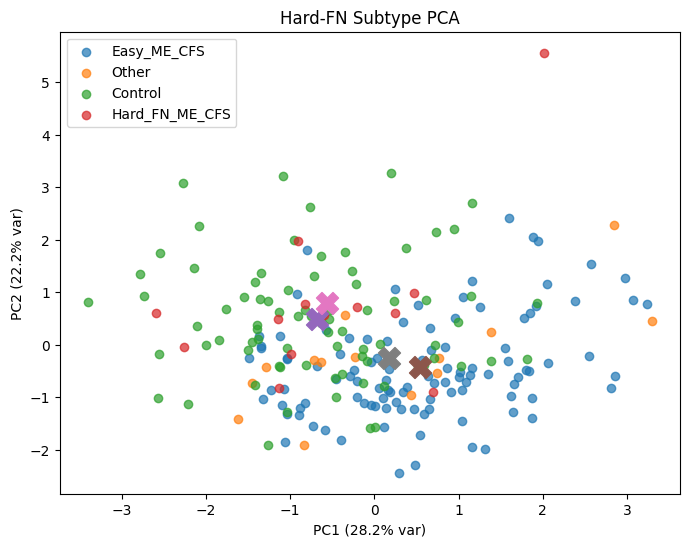


Explained variance:
[0.28209168 0.22222261]
Total: 0.5043142978500545


In [83]:
# =========================
# PCA of Hard-FN subtype
# =========================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

SUBTYPE_FEATURES = [
    "sphingomyelin (d18:1/24:1, d18:2/24:0)*",
    "3-(4-hydroxyphenyl)lactate",
    "vanillylmandelate (VMA)",
    "4-vinylguaiacol sulfate",
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)",
    "N-palmitoyl-sphingosine (d18:1/16:0)"
]

# -------------------------
# Build PCA matrix
# -------------------------

X_sub = X[SUBTYPE_FEATURES].copy()

X_scaled = StandardScaler().fit_transform(X_sub)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": pcs[:,0],
    "PC2": pcs[:,1],
    "label": y.values
}, index=X.index)

# -------------------------
# Hard-FN definition
# -------------------------

hard_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] >= 0.80)
]["index"].tolist()

easy_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] <= 0.05)
]["index"].tolist()

plot_df["group"] = "Other"

plot_df.loc[y[y==0].index, "group"] = "Control"

plot_df.loc[
    plot_df.index.intersection(easy_idx),
    "group"
] = "Easy_ME_CFS"

plot_df.loc[
    plot_df.index.intersection(hard_idx),
    "group"
] = "Hard_FN_ME_CFS"

print(plot_df["group"].value_counts())

# -------------------------
# Centroids
# -------------------------

centroids = (
    plot_df
    .groupby("group")[["PC1","PC2"]]
    .mean()
)

print("\nCentroids:")
display(centroids)

# -------------------------
# Distances
# -------------------------

control_centroid = centroids.loc["Control"].values.reshape(1,-1)
easy_centroid = centroids.loc["Easy_ME_CFS"].values.reshape(1,-1)
hard_centroid = centroids.loc["Hard_FN_ME_CFS"].values.reshape(1,-1)

dist_hard_to_control = cdist(
    hard_centroid,
    control_centroid
)[0][0]

dist_hard_to_easy = cdist(
    hard_centroid,
    easy_centroid
)[0][0]

dist_easy_to_control = cdist(
    easy_centroid,
    control_centroid
)[0][0]

print("\nDistances:")
print("Hard -> Control :", dist_hard_to_control)
print("Hard -> Easy    :", dist_hard_to_easy)
print("Easy -> Control :", dist_easy_to_control)

if dist_hard_to_control < dist_hard_to_easy:
    print("\nHard-FN group is closer to Controls.")
else:
    print("\nHard-FN group is closer to Easy ME/CFS.")

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(8,6))

for grp in plot_df["group"].unique():

    d = plot_df[plot_df["group"] == grp]

    plt.scatter(
        d["PC1"],
        d["PC2"],
        alpha=0.7,
        label=grp
    )

for grp in centroids.index:

    plt.scatter(
        centroids.loc[grp,"PC1"],
        centroids.loc[grp,"PC2"],
        s=250,
        marker="X"
    )

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)"
)
plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)"
)

plt.title("Hard-FN Subtype PCA")
plt.legend()
plt.show()

print("\nExplained variance:")
print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

In [84]:
# =========================
# Hard-FN ME/CFS clinical/omics identity search
# =========================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

# groups
hard_fn_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] >= 0.80)
]["index"].tolist()

easy_idx = error_df[
    (error_df["true_label"] == 1) &
    (error_df["FN_rate_when_tested"] <= 0.05)
]["index"].tolist()

print("Hard-FN ME/CFS:", len(hard_fn_idx))
print("Easy ME/CFS:", len(easy_idx))

# gather candidate tables already in notebook
candidate_tables = {}
for name in [
    "meta_tp1", "meta_raw", "df",
    "quest", "quest_df",
    "immune", "immune_df",
    "kegg", "kegg_df",
    "species", "species_df",
    "X_multi"
]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        candidate_tables[name] = globals()[name]

print("\nTables found:")
for name, table in candidate_tables.items():
    print(name, table.shape)

def compare_table(table, table_name):
    rows = []

    shared_hard = [i for i in hard_fn_idx if i in table.index]
    shared_easy = [i for i in easy_idx if i in table.index]

    if len(shared_hard) < 3 or len(shared_easy) < 3:
        return pd.DataFrame()

    for col in table.columns:
        s = table[col]

        # numeric
        if pd.api.types.is_numeric_dtype(s):
            a = table.loc[shared_hard, col].dropna()
            b = table.loc[shared_easy, col].dropna()

            if len(a) < 3 or len(b) < 3:
                continue

            try:
                _, p = mannwhitneyu(a, b, alternative="two-sided")
            except:
                continue

            pooled = np.sqrt((a.var() + b.var()) / 2)
            d = np.nan if pooled == 0 else (a.mean() - b.mean()) / pooled

            rows.append({
                "table": table_name,
                "feature": col,
                "type": "numeric",
                "hard_mean": a.mean(),
                "easy_mean": b.mean(),
                "difference": a.mean() - b.mean(),
                "cohens_d": d,
                "p": p,
                "n_hard": len(a),
                "n_easy": len(b)
            })

        # categorical
        else:
            vals = table.loc[shared_hard + shared_easy, col].dropna()

            if vals.nunique() < 2 or vals.nunique() > 12:
                continue

            for level in vals.unique():
                hard_yes = (table.loc[shared_hard, col] == level).sum()
                easy_yes = (table.loc[shared_easy, col] == level).sum()

                hard_no = len(shared_hard) - hard_yes
                easy_no = len(shared_easy) - easy_yes

                try:
                    _, p = fisher_exact([[hard_yes, hard_no], [easy_yes, easy_no]])
                except:
                    continue

                rows.append({
                    "table": table_name,
                    "feature": f"{col} == {level}",
                    "type": "categorical",
                    "hard_mean": hard_yes / len(shared_hard),
                    "easy_mean": easy_yes / len(shared_easy),
                    "difference": hard_yes / len(shared_hard) - easy_yes / len(shared_easy),
                    "cohens_d": np.nan,
                    "p": p,
                    "n_hard": len(shared_hard),
                    "n_easy": len(shared_easy)
                })

    out = pd.DataFrame(rows)
    if len(out):
        out["fdr"] = multipletests(out["p"], method="fdr_bh")[1]
    return out

all_results = []
for name, table in candidate_tables.items():
    res = compare_table(table, name)
    if len(res):
        all_results.append(res)

identity_results = pd.concat(all_results, ignore_index=True)

print("\nTotal tested:", len(identity_results))

print("\n===== FDR-significant features =====")
display(
    identity_results[identity_results["fdr"] < 0.10]
    .sort_values("fdr")
    .head(100)
)

print("\n===== Top by p-value =====")
display(
    identity_results.sort_values("p").head(75)
)

print("\n===== Strongest higher in hard-FN =====")
display(
    identity_results.sort_values("cohens_d", ascending=False).head(50)
)

print("\n===== Strongest lower in hard-FN =====")
display(
    identity_results.sort_values("cohens_d", ascending=True).head(50)
)

# table-level summary
print("\n===== Best signals by table =====")
table_summary = (
    identity_results
    .groupby("table")
    .agg(
        n_tested=("feature", "count"),
        min_p=("p", "min"),
        n_fdr_10=("fdr", lambda x: (x < 0.10).sum()),
        n_fdr_20=("fdr", lambda x: (x < 0.20).sum())
    )
    .sort_values(["n_fdr_10", "min_p"], ascending=[False, True])
)
display(table_summary)

Hard-FN ME/CFS: 13
Easy ME/CFS: 108

Tables found:
meta_tp1 (249, 23)
meta_raw (515, 23)
df (214, 901)

Total tested: 960

===== FDR-significant features =====


,table,feature,type,hard_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr



===== Top by p-value =====


,table,feature,type,hard_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr
108,df,2'-deoxyuridine,numeric,1.961986,1.377221,0.584765,1.196825,0.000381,13,108,0.139309
306,df,isovalerylcarnitine (C5),numeric,1.407359,0.968376,0.438983,1.042897,0.000475,13,108,0.139309
923,df,X-25265,numeric,1.262593,1.145183,0.117411,1.218956,0.000522,13,108,0.139309
112,df,tryptophan,numeric,1.168137,0.993252,0.174885,1.136735,0.000689,13,108,0.139309
522,df,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",numeric,1.503681,2.252830,-0.749149,-1.099705,0.000802,13,108,0.139309
...,...,...,...,...,...,...,...,...,...,...,...
179,df,eicosapentaenoate (EPA; 20:5n3),numeric,0.369037,0.657593,-0.288556,-0.511411,0.021114,13,108,0.268234
726,df,"N6,N6-dimethyllysine",numeric,1.824522,1.364905,0.459616,0.682327,0.021586,13,108,0.268985
584,df,"sphingomyelin (d18:2/24:1, d18:1/24:2)*",numeric,1.042270,1.191177,-0.148907,-0.755086,0.022068,13,108,0.268985
571,df,1-stearoyl-2-oleoyl-GPC (18:0/18:1),numeric,1.248117,1.343245,-0.095127,-0.251513,0.022068,13,108,0.268985



===== Strongest higher in hard-FN =====


,table,feature,type,hard_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr
923,df,X-25265,numeric,1.262593,1.145183,0.117411,1.218956,0.000522,13,108,0.139309
108,df,2'-deoxyuridine,numeric,1.961986,1.377221,0.584765,1.196825,0.000381,13,108,0.139309
112,df,tryptophan,numeric,1.168137,0.993252,0.174885,1.136735,0.000689,13,108,0.139309
306,df,isovalerylcarnitine (C5),numeric,1.407359,0.968376,0.438983,1.042897,0.000475,13,108,0.139309
5,meta_tp1,age,numeric,57.000000,46.326531,10.673469,0.975503,0.133859,4,49,0.899232
484,df,N-acetylcarnosine,numeric,1.738428,1.055294,0.683134,0.941583,0.001081,13,108,0.139309
513,df,N-methylpipecolate,numeric,3.977450,2.090499,1.886951,0.926716,0.001050,13,108,0.139309
322,df,5-methyluridine (ribothymidine),numeric,1.432890,1.259941,0.172949,0.851372,0.006775,13,108,0.197131
128,df,xanthine,numeric,1.633986,1.264336,0.369651,0.849156,0.005114,13,108,0.165748
211,df,alpha-hydroxyisocaproate,numeric,1.185126,0.883862,0.301264,0.828426,0.004039,13,108,0.165748



===== Strongest lower in hard-FN =====


,table,feature,type,hard_mean,easy_mean,difference,cohens_d,p,n_hard,n_easy,fdr
18,meta_tp1,diet_grains,numeric,1.750000,3.061224,-1.311224e+00,-1.348127,0.023250,4,49,0.627755
522,df,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",numeric,1.503681,2.252830,-7.491487e-01,-1.099705,0.000802,13,108,0.139309
665,df,"sphingomyelin (d18:2/21:0, d16:2/23:0)*",numeric,1.564437,2.087143,-5.227057e-01,-0.966681,0.003535,13,108,0.165748
666,df,sphingomyelin (d18:2/23:1)*,numeric,1.191430,1.628369,-4.369393e-01,-0.940391,0.004855,13,108,0.165748
896,df,X-23782,numeric,0.902133,1.388719,-4.865861e-01,-0.904650,0.007873,13,108,0.202888
16,meta_tp1,diet_sugar,numeric,2.000000,3.040816,-1.040816e+00,-0.881231,0.098828,4,49,0.899232
199,df,theobromine,numeric,0.614190,3.139232,-2.525042e+00,-0.860007,0.005332,13,108,0.165748
831,df,X-13728,numeric,0.976908,3.090400,-2.113492e+00,-0.837860,0.040519,13,108,0.316554
931,df,X-25520,numeric,0.579472,1.191282,-6.118096e-01,-0.810744,0.003881,13,108,0.165748
583,df,"sphingomyelin (d18:2/23:0, d18:1/23:1, d17:1/2...",numeric,1.536295,1.962984,-4.266896e-01,-0.809914,0.013385,13,108,0.223587



===== Best signals by table =====


,n_tested,min_p,n_fdr_10,n_fdr_20
table,,,,
df,902,0.000381,0,31
meta_tp1,27,0.023250,0,0
meta_raw,31,0.128992,0,0


In [86]:
# =========================
# Omics-layer rescue benchmark:
# Can any layer identify hard-FN ME/CFS cases?
# =========================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -------------------------
# Settings
# -------------------------

N_SPLITS = 100
TOP_K = 10

HARD_FN_PROB_CUT = 0.50
EASY_CASE_PROB_CUT = 0.80

# -------------------------
# Gather available layers
# -------------------------

layers = {}

for name in [
    "X", "quest_df", "quest",
    "immune_df", "immune",
    "kegg_df", "kegg",
    "species_df", "species",
    "X_multi"
]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        layers[name] = globals()[name].copy()

print("Layers found:")
for name, table in layers.items():
    print(name, table.shape)

# -------------------------
# Helper: train-only feature ranking
# -------------------------

def select_top_features_train_only(X_layer_train, hard_idx, easy_idx, top_k=10):
    rows = []

    hard_idx = [i for i in hard_idx if i in X_layer_train.index]
    easy_idx = [i for i in easy_idx if i in X_layer_train.index]

    if len(hard_idx) < 5 or len(easy_idx) < 15:
        return []

    for feat in X_layer_train.columns:
        if not pd.api.types.is_numeric_dtype(X_layer_train[feat]):
            continue

        a = X_layer_train.loc[hard_idx, feat].dropna()
        b = X_layer_train.loc[easy_idx, feat].dropna()

        if len(a) < 5 or len(b) < 15:
            continue

        try:
            _, p = mannwhitneyu(a, b, alternative="two-sided")
        except Exception:
            continue

        pooled = np.sqrt((a.var() + b.var()) / 2)
        d = 0 if pooled == 0 else (a.mean() - b.mean()) / pooled

        rows.append({
            "feature": feat,
            "p": p,
            "abs_d": abs(d),
            "cohens_d": d
        })

    if len(rows) == 0:
        return []

    rank_df = pd.DataFrame(rows)
    rank_df["fdr"] = multipletests(rank_df["p"], method="fdr_bh")[1]

    return (
        rank_df
        .sort_values(["p", "abs_d"], ascending=[True, False])
        .head(top_k)["feature"]
        .tolist()
    )

# -------------------------
# Main benchmark
# -------------------------

all_rows = []

for seed in range(N_SPLITS):

    train_idx, test_idx = train_test_split(
        X.index,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    X_train_main = X.loc[train_idx, LOCKED_PANEL]
    X_test_main = X.loc[test_idx, LOCKED_PANEL]

    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    # Main locked-10 model
    main_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    main_model.fit(X_train_main, y_train)

    train_probs = pd.Series(
        main_model.predict_proba(X_train_main)[:, 1],
        index=train_idx
    )

    test_probs = pd.Series(
        main_model.predict_proba(X_test_main)[:, 1],
        index=test_idx
    )

    # Define hard/easy ME/CFS inside train and test separately
    train_cases = y_train[y_train == 1].index
    test_cases = y_test[y_test == 1].index

    train_hard = train_cases[train_probs.loc[train_cases] < HARD_FN_PROB_CUT]
    train_easy = train_cases[train_probs.loc[train_cases] >= EASY_CASE_PROB_CUT]

    test_hard = test_cases[test_probs.loc[test_cases] < HARD_FN_PROB_CUT]
    test_easy = test_cases[test_probs.loc[test_cases] >= EASY_CASE_PROB_CUT]

    if len(train_hard) < 5 or len(train_easy) < 15:
        continue

    if len(test_hard) < 2 or len(test_easy) < 5:
        continue

    for layer_name, layer in layers.items():

        shared_train_hard = [i for i in train_hard if i in layer.index]
        shared_train_easy = [i for i in train_easy if i in layer.index]
        shared_test_hard = [i for i in test_hard if i in layer.index]
        shared_test_easy = [i for i in test_easy if i in layer.index]

        if len(shared_train_hard) < 5 or len(shared_train_easy) < 15:
            continue

        if len(shared_test_hard) < 2 or len(shared_test_easy) < 5:
            continue

        X_layer_train = layer.loc[train_idx.intersection(layer.index)].copy()
        X_layer_test = layer.loc[test_idx.intersection(layer.index)].copy()

        selected_features = select_top_features_train_only(
            X_layer_train,
            shared_train_hard,
            shared_train_easy,
            top_k=TOP_K
        )

        if len(selected_features) < 3:
            continue

        subtype_train_idx = list(shared_train_hard) + list(shared_train_easy)
        subtype_test_idx = list(shared_test_hard) + list(shared_test_easy)

        X_sub_train = layer.loc[subtype_train_idx, selected_features]
        X_sub_test = layer.loc[subtype_test_idx, selected_features]

        y_sub_train = pd.Series(
            [1 if i in shared_train_hard else 0 for i in subtype_train_idx],
            index=subtype_train_idx
        )

        y_sub_test = pd.Series(
            [1 if i in shared_test_hard else 0 for i in subtype_test_idx],
            index=subtype_test_idx
        )

        rescue_model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=seed
            ))
        ])

        try:
            rescue_model.fit(X_sub_train, y_sub_train)
            rescue_probs = rescue_model.predict_proba(X_sub_test)[:, 1]
            auc = roc_auc_score(y_sub_test, rescue_probs)
        except Exception:
            continue

        all_rows.append({
            "seed": seed,
            "layer": layer_name,
            "rescue_auc": auc,
            "n_train_hard": len(shared_train_hard),
            "n_train_easy": len(shared_train_easy),
            "n_test_hard": len(shared_test_hard),
            "n_test_easy": len(shared_test_easy),
            "features": " | ".join(selected_features)
        })

    if seed % 10 == 0:
        print("Finished seed", seed)

layer_rescue_results = pd.DataFrame(all_rows)

print("\nCompleted rows:", len(layer_rescue_results))

# -------------------------
# Summary
# -------------------------

summary = (
    layer_rescue_results
    .groupby("layer")["rescue_auc"]
    .agg(
        n_valid="count",
        mean_auc="mean",
        median_auc="median",
        std_auc="std",
        q05=lambda x: x.quantile(0.05),
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q95=lambda x: x.quantile(0.95)
    )
    .sort_values("mean_auc", ascending=False)
)

print("\n===== OMICS-LAYER RESCUE SUMMARY =====")
display(summary)

# -------------------------
# Stable features per layer
# -------------------------

from collections import Counter

for layer_name in summary.index:
    counter = Counter()

    sub = layer_rescue_results[layer_rescue_results["layer"] == layer_name]

    for fs in sub["features"]:
        for f in fs.split(" | "):
            counter[f] += 1

    stable = pd.DataFrame({
        "feature": list(counter.keys()),
        "count": list(counter.values())
    }).sort_values("count", ascending=False)

    stable["frequency"] = stable["count"] / len(sub)

    print(f"\n===== Stable rescue features: {layer_name} =====")
    display(stable.head(30))

Layers found:
X (214, 876)
Finished seed 0
Finished seed 10
Finished seed 20
Finished seed 30
Finished seed 40
Finished seed 50
Finished seed 60
Finished seed 70
Finished seed 80

Completed rows: 87

===== OMICS-LAYER RESCUE SUMMARY =====


,n_valid,mean_auc,median_auc,std_auc,q05,q25,q75,q95
layer,,,,,,,,
X,87,0.796871,0.822917,0.144422,0.557639,0.685417,0.905506,1.0



===== Stable rescue features: X =====


,feature,count,frequency
1,N-palmitoyl-sphinganine (d18:0/16:0),75,0.862069
10,tryptophan,57,0.655172
0,1-stearoyl-2-docosahexaenoyl-GPE (18:0/22:6)*,44,0.505747
3,tricosanoyl sphingomyelin (d18:1/23:0)*,44,0.505747
9,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",32,0.367816
11,2'-deoxyuridine,31,0.356322
15,"sphingomyelin (d18:2/14:0, d18:1/14:1)*",30,0.344828
16,sphingomyelin (d18:2/23:1)*,29,0.333333
19,4-vinylguaiacol sulfate,29,0.333333
21,1-stearoyl-2-oleoyl-GPC (18:0/18:1),28,0.321839


In [87]:
RESCUE_FEATURES = [
    "N-palmitoyl-sphinganine (d18:0/16:0)",
    "tryptophan",
    "1-stearoyl-2-docosahexaenoyl-GPE (18:0/22:6)*",
    "tricosanoyl sphingomyelin (d18:1/23:0)*",
    "sphingomyelin (d18:1/24:1, d18:2/24:0)*",
    "2'-deoxyuridine",
    "sphingomyelin (d18:2/14:0, d18:1/14:1)*",
    "sphingomyelin (d18:2/23:1)*",
    "4-vinylguaiacol sulfate",
    "N4-acetylcytidine"
]

In [88]:
# =========================
# Locked10 + Rescue Pipeline
# =========================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd

N_SPLITS = 500

results = []

for seed in range(N_SPLITS):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    # -----------------
    # Main model
    # -----------------

    main_model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    main_model.fit(
        X_train[LOCKED_PANEL],
        y_train
    )

    train_probs = pd.Series(
        main_model.predict_proba(
            X_train[LOCKED_PANEL]
        )[:,1],
        index=X_train.index
    )

    test_probs = pd.Series(
        main_model.predict_proba(
            X_test[LOCKED_PANEL]
        )[:,1],
        index=X_test.index
    )

    # -----------------
    # define hard/easy on TRAIN ONLY
    # -----------------

    train_cases = y_train[y_train == 1].index

    hard_train = train_cases[
        train_probs.loc[train_cases] < 0.50
    ]

    easy_train = train_cases[
        train_probs.loc[train_cases] >= 0.80
    ]

    if len(hard_train) < 5:
        continue

    rescue_idx = list(hard_train) + list(easy_train)

    rescue_y = pd.Series(
        [1]*len(hard_train) +
        [0]*len(easy_train),
        index=rescue_idx
    )

    rescue_model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=seed
        ))
    ])

    rescue_model.fit(
        X_train.loc[rescue_idx, RESCUE_FEATURES],
        rescue_y
    )

    # -----------------
    # ORIGINAL
    # -----------------

    original_pred = (test_probs >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        original_pred
    ).ravel()

    original_auc = roc_auc_score(
        y_test,
        test_probs
    )

    # -----------------
    # RESCUED
    # -----------------

    rescued_pred = original_pred.copy()

    low_confidence = test_probs < 0.50

    if low_confidence.sum() > 0:

        rescue_probs = rescue_model.predict_proba(
            X_test.loc[
                low_confidence,
                RESCUE_FEATURES
            ]
        )[:,1]

        rescued_pred.loc[
            low_confidence
        ] = (rescue_probs >= 0.50).astype(int)

    tn2, fp2, fn2, tp2 = confusion_matrix(
        y_test,
        rescued_pred
    ).ravel()

    results.append({
        "orig_auc": original_auc,
        "orig_FN": fn,
        "orig_FP": fp,
        "orig_sens": tp/(tp+fn),
        "orig_spec": tn/(tn+fp),

        "resc_FN": fn2,
        "resc_FP": fp2,
        "resc_sens": tp2/(tp2+fn2),
        "resc_spec": tn2/(tn2+fp2)
    })

results = pd.DataFrame(results)

print("===== ORIGINAL =====")
print(results[
    ["orig_auc","orig_FN","orig_FP",
     "orig_sens","orig_spec"]
].mean())

print("\n===== RESCUED =====")
print(results[
    ["resc_FN","resc_FP",
     "resc_sens","resc_spec"]
].mean())

print("\n===== CHANGE =====")
print(
    pd.Series({
        "delta_FN":
            results["resc_FN"].mean()
            - results["orig_FN"].mean(),

        "delta_FP":
            results["resc_FP"].mean()
            - results["orig_FP"].mean(),

        "delta_sens":
            results["resc_sens"].mean()
            - results["orig_sens"].mean(),

        "delta_spec":
            results["resc_spec"].mean()
            - results["orig_spec"].mean()
    })
)

===== ORIGINAL =====
orig_auc     0.859014
orig_FN      3.484000
orig_FP      4.840000
orig_sens    0.870963
orig_spec    0.697500
dtype: float64

===== RESCUED =====
resc_FN       0.832000
resc_FP      12.148000
resc_sens     0.969185
resc_spec     0.240750
dtype: float64

===== CHANGE =====
delta_FN     -2.652000
delta_FP      7.308000
delta_sens    0.098222
delta_spec   -0.456750
dtype: float64


In [91]:
score_df


,y_true,prob_ME_CFS
0,0,0.463914
1,1,0.937344
2,1,0.645037
3,0,0.073912
4,1,0.733689
5,0,0.870237
6,1,0.601074
7,1,0.890764
8,0,0.116010
9,1,0.614990


In [92]:
# =========================
# 3-zone decision rule for locked 10 score
# Uses existing score_df
# =========================

import numpy as np
import pandas as pd

print(score_df.columns)

# Auto-detect columns
label_col = None
prob_col = None

for c in score_df.columns:
    if c.lower() in ["label", "true_label", "y_true", "study_ptorhc"]:
        label_col = c

for c in score_df.columns:
    if "prob" in c.lower() or "score" in c.lower():
        prob_col = c

print("Using label column:", label_col)
print("Using probability column:", prob_col)

scores = score_df[[label_col, prob_col]].copy()
scores = scores.rename(columns={label_col: "true_label", prob_col: "prob_ME_CFS"})

results = []

for low_cut in np.arange(0.05, 0.51, 0.01):
    for high_cut in np.arange(0.50, 0.96, 0.01):

        if high_cut <= low_cut:
            continue

        called_low = scores[scores["prob_ME_CFS"] <= low_cut].copy()
        called_high = scores[scores["prob_ME_CFS"] >= high_cut].copy()
        called = pd.concat([called_low, called_high])

        if len(called) < 5:
            continue

        called["pred"] = np.where(
            called["prob_ME_CFS"] >= high_cut,
            1,
            0
        )

        TP = ((called["true_label"] == 1) & (called["pred"] == 1)).sum()
        TN = ((called["true_label"] == 0) & (called["pred"] == 0)).sum()
        FP = ((called["true_label"] == 0) & (called["pred"] == 1)).sum()
        FN = ((called["true_label"] == 1) & (called["pred"] == 0)).sum()

        n_called = len(called)
        n_total = len(scores)
        n_inconclusive = n_total - n_called

        accuracy_called = (TP + TN) / n_called
        coverage = n_called / n_total

        sensitivity_called = TP / (TP + FN) if (TP + FN) > 0 else np.nan
        specificity_called = TN / (TN + FP) if (TN + FP) > 0 else np.nan

        results.append({
            "low_cut": round(low_cut, 2),
            "high_cut": round(high_cut, 2),
            "n_total": n_total,
            "n_called": n_called,
            "n_inconclusive": n_inconclusive,
            "coverage": coverage,
            "accuracy_called": accuracy_called,
            "TP": TP,
            "TN": TN,
            "FP": FP,
            "FN": FN,
            "sensitivity_called": sensitivity_called,
            "specificity_called": specificity_called
        })

triage_df = pd.DataFrame(results)

print("\n===== Best overall tradeoffs =====")
display(
    triage_df
    .sort_values(["accuracy_called", "coverage"], ascending=[False, False])
    .head(30)
)

print("\n===== Best with >=90% called accuracy =====")
display(
    triage_df[triage_df["accuracy_called"] >= 0.90]
    .sort_values("coverage", ascending=False)
    .head(30)
)

print("\n===== Best with >=95% called accuracy =====")
display(
    triage_df[triage_df["accuracy_called"] >= 0.95]
    .sort_values("coverage", ascending=False)
    .head(30)
)

print("\n===== Perfect called accuracy if any =====")
display(
    triage_df[triage_df["accuracy_called"] == 1.0]
    .sort_values("coverage", ascending=False)
    .head(30)
)

Index(['y_true', 'prob_ME_CFS'], dtype='object')
Using label column: y_true
Using probability column: prob_ME_CFS

===== Best overall tradeoffs =====


,low_cut,high_cut,n_total,n_called,n_inconclusive,coverage,accuracy_called,TP,TN,FP,FN,sensitivity_called,specificity_called
361,0.12,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
407,0.13,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
453,0.14,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
499,0.15,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
177,0.08,0.89,43,19,24,0.441860,1.0,14,5,0,0,1.0,1.0
223,0.09,0.89,43,19,24,0.441860,1.0,14,5,0,0,1.0,1.0
269,0.10,0.89,43,19,24,0.441860,1.0,14,5,0,0,1.0,1.0
315,0.11,0.89,43,19,24,0.441860,1.0,14,5,0,0,1.0,1.0
362,0.12,0.90,43,19,24,0.441860,1.0,13,6,0,0,1.0,1.0
363,0.12,0.91,43,19,24,0.441860,1.0,13,6,0,0,1.0,1.0



===== Best with >=90% called accuracy =====


,low_cut,high_cut,n_total,n_called,n_inconclusive,coverage,accuracy_called,TP,TN,FP,FN,sensitivity_called,specificity_called
1143,0.29,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1695,0.41,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1511,0.37,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1419,0.35,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1097,0.28,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1557,0.38,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1373,0.34,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1603,0.39,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1649,0.40,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00
1327,0.33,0.89,43,25,18,0.581395,0.920000,14,9,0,2,0.875000,1.00



===== Best with >=95% called accuracy =====


,low_cut,high_cut,n_total,n_called,n_inconclusive,coverage,accuracy_called,TP,TN,FP,FN,sensitivity_called,specificity_called
1051,0.27,0.89,43,23,20,0.534884,0.956522,14,8,0,1,0.933333,1.000000
1005,0.26,0.89,43,23,20,0.534884,0.956522,14,8,0,1,0.933333,1.000000
867,0.23,0.89,43,22,21,0.511628,0.954545,14,7,0,1,0.933333,1.000000
1053,0.27,0.91,43,22,21,0.511628,0.954545,13,8,0,1,0.928571,1.000000
1052,0.27,0.90,43,22,21,0.511628,0.954545,13,8,0,1,0.928571,1.000000
729,0.20,0.89,43,22,21,0.511628,0.954545,14,7,0,1,0.933333,1.000000
1007,0.26,0.91,43,22,21,0.511628,0.954545,13,8,0,1,0.928571,1.000000
1006,0.26,0.90,43,22,21,0.511628,0.954545,13,8,0,1,0.928571,1.000000
775,0.21,0.89,43,22,21,0.511628,0.954545,14,7,0,1,0.933333,1.000000
913,0.24,0.89,43,22,21,0.511628,0.954545,14,7,0,1,0.933333,1.000000



===== Perfect called accuracy if any =====


,low_cut,high_cut,n_total,n_called,n_inconclusive,coverage,accuracy_called,TP,TN,FP,FN,sensitivity_called,specificity_called
407,0.13,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
499,0.15,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
361,0.12,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
453,0.14,0.89,43,20,23,0.465116,1.0,14,6,0,0,1.0,1.0
455,0.14,0.91,43,19,24,0.441860,1.0,13,6,0,0,1.0,1.0
363,0.12,0.91,43,19,24,0.441860,1.0,13,6,0,0,1.0,1.0
362,0.12,0.90,43,19,24,0.441860,1.0,13,6,0,0,1.0,1.0
408,0.13,0.90,43,19,24,0.441860,1.0,13,6,0,0,1.0,1.0
409,0.13,0.91,43,19,24,0.441860,1.0,13,6,0,0,1.0,1.0
223,0.09,0.89,43,19,24,0.441860,1.0,14,5,0,0,1.0,1.0


In [93]:
# =========================
# 500-split robustness for 3-zone locked-10 rule
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

LOW_CUT = 0.13
HIGH_CUT = 0.89
N_SPLITS = 500

rows = []

X10 = X[LOCKED_PANEL].copy()
y10 = y.copy()

for seed in range(N_SPLITS):

    X_train, X_test, y_train, y_test = train_test_split(
        X10, y10,
        test_size=0.20,
        stratify=y10,
        random_state=seed
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    model.fit(X_train, y_train)
    probs = pd.Series(model.predict_proba(X_test)[:, 1], index=y_test.index)

    called_mask = (probs <= LOW_CUT) | (probs >= HIGH_CUT)
    called_probs = probs[called_mask]
    called_true = y_test.loc[called_mask]

    preds = pd.Series(index=called_probs.index, dtype=int)
    preds[called_probs <= LOW_CUT] = 0
    preds[called_probs >= HIGH_CUT] = 1

    TP = ((called_true == 1) & (preds == 1)).sum()
    TN = ((called_true == 0) & (preds == 0)).sum()
    FP = ((called_true == 0) & (preds == 1)).sum()
    FN = ((called_true == 1) & (preds == 0)).sum()

    n_called = len(called_true)
    n_total = len(y_test)

    rows.append({
        "seed": seed,
        "n_total": n_total,
        "n_called": n_called,
        "n_inconclusive": n_total - n_called,
        "coverage": n_called / n_total,
        "called_accuracy": (TP + TN) / n_called if n_called > 0 else np.nan,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "called_sensitivity": TP / (TP + FN) if (TP + FN) > 0 else np.nan,
        "called_specificity": TN / (TN + FP) if (TN + FP) > 0 else np.nan
    })

triage_robustness = pd.DataFrame(rows)

print("===== 3-ZONE ROBUSTNESS =====")
print("Low cut:", LOW_CUT)
print("High cut:", HIGH_CUT)

display(
    triage_robustness
    .agg({
        "coverage": ["mean", "median", "std", "min", "max"],
        "called_accuracy": ["mean", "median", "std", "min", "max"],
        "n_called": ["mean", "median", "std", "min", "max"],
        "n_inconclusive": ["mean", "median", "std", "min", "max"],
        "FP": ["mean", "median", "std", "min", "max"],
        "FN": ["mean", "median", "std", "min", "max"],
        "called_sensitivity": ["mean", "median", "std", "min", "max"],
        "called_specificity": ["mean", "median", "std", "min", "max"]
    })
)

print("\n===== Quantiles =====")
display(
    triage_robustness[
        ["coverage", "called_accuracy", "n_called", "n_inconclusive", "FP", "FN",
         "called_sensitivity", "called_specificity"]
    ].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
)

print("\nSplits with perfect called accuracy:")
print((triage_robustness["called_accuracy"] == 1.0).mean())

print("\nSplits with called accuracy >= 0.95:")
print((triage_robustness["called_accuracy"] >= 0.95).mean())

===== 3-ZONE ROBUSTNESS =====
Low cut: 0.13
High cut: 0.89


,coverage,called_accuracy,n_called,n_inconclusive,FP,FN,called_sensitivity,called_specificity
mean,0.404186,0.933367,17.380000,25.620000,0.826000,0.384000,0.967595,0.855094
median,0.395349,0.941176,17.000000,26.000000,1.000000,0.000000,1.000000,0.875000
std,0.076132,0.063028,3.273688,3.273688,0.949488,0.636675,0.054118,0.167978
min,0.186047,0.705882,8.000000,15.000000,0.000000,0.000000,0.750000,0.000000
max,0.651163,1.000000,28.000000,35.000000,5.000000,3.000000,1.000000,1.000000



===== Quantiles =====


,coverage,called_accuracy,n_called,n_inconclusive,FP,FN,called_sensitivity,called_specificity
0.05,0.279070,0.818182,12.0,20.0,0.0,0.0,0.846154,0.500
0.25,0.348837,0.891865,15.0,23.0,0.0,0.0,0.928571,0.750
0.50,0.395349,0.941176,17.0,26.0,1.0,0.0,1.000000,0.875
0.75,0.465116,1.000000,20.0,28.0,1.0,1.0,1.000000,1.000
0.95,0.534884,1.000000,23.0,31.0,3.0,2.0,1.000000,1.000



Splits with perfect called accuracy:
0.354

Splits with called accuracy >= 0.95:
0.394
